In [ ]:
# بسم الله الرحمن الرحیم

In [4]:
import torchaudio

print(torchaudio.__version__)
# ابزار فورس‌الاینر رسمی تورچ‌آدیو:
from torchaudio.pipelines import (
    MMS_FA as bundle,
)  # مدل چندزبانه فوق‌العاده قوی متا برای Alignment
# یا جایگزین کلاسیک انگلیسی: torchaudio.pipelines.WAV2VEC2_ASR_BASE_960H


2.6.0+cu124


In [ ]:
import os
from pathlib import Path
import torch
import torchaudio

# مسیر پوشه مدل‌های شما (پوشه را در صورت نیاز اصلاح کنید)
PRETRAINED_DIR = Path("./pretrained_models/mms_fa")
PRETRAINED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Downloading/Loading MMS_FA aligner to: {PRETRAINED_DIR.resolve()} ...")

# انتخاب باندل MMS_FA
bundle = torchaudio.pipelines.MMS_FA

# هدایت مستقیم محل دانلود فایل چک‌پوینت به پوشه اختصاصی
aligner_model = bundle.get_model(
    dl_kwargs={"model_dir": str(PRETRAINED_DIR.resolve())}
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
aligner_model = aligner_model.to(device).eval()

tokenizer = bundle.get_tokenizer()
aligner_dict = bundle.get_dict()

print(" Align model loaded successfully without touching default cache!")


In [9]:
PRETRAINED_DIR = Path("./pretrained_models/mms_fa")
# انتخاب باندل MMS_FA
bundle = torchaudio.pipelines.MMS_FA

# هدایت مستقیم محل دانلود فایل چک‌پوینت به پوشه اختصاصی
aligner_model = bundle.get_model(
    dl_kwargs={"model_dir": str(PRETRAINED_DIR.resolve())}
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
aligner_model = aligner_model.to(device).eval()

tokenizer = bundle.get_tokenizer()
aligner_dict = bundle.get_dict()

print(" Align model loaded successfully without touching default cache!")


 Align model loaded successfully without touching default cache!


In [10]:
import re
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchaudio
from pathlib import Path

# Assuming these are defined elsewhere in your code
# aligner_model, aligner_dict, and device should be defined
# For example:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# aligner_model = ...  # Your MMS alignment model
# aligner_dict = ...   # Your character dictionary


def align_single_audio(
    audio_path, transcript_text, target_sample_rate=16000, frame_shift_sec=0.02
):
    """صوت و متن را گرفته و برچسب هر فریم 20ms را استخراج می‌کند."""
    # ۱. بارگذاری و Resample صوت
    waveform, sr = torchaudio.load(audio_path)
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    if sr != target_sample_rate:
        resampler = torchaudio.transforms.Resample(sr, target_sample_rate)
        waveform = resampler(waveform)

    waveform = waveform.to(device)

    # ۲. نرمال‌سازی متن برای دیکشنری MMS
    clean_text = transcript_text.lower().strip()
    clean_text = re.sub(r"[^a-z'\s]", "", clean_text)
    # اضافه کردن فاصله بین کلمات بر اساس فرمت MMS
    clean_text = clean_text.replace(" ", "*")

    # توکنایز کردن متن
    tokens = [aligner_dict[c] for c in clean_text if c in aligner_dict]
    targets = torch.tensor([tokens], dtype=torch.int32, device=device)

    # ۳. استخراج احتمالات فریم‌ها (Emission)
    with torch.inference_mode():
        emission, _ = aligner_model(waveform)

    # ۴. اجرای CTC Forced Alignment توکار torchaudio
    # Fix: Remove blank_id parameter or use correct signature for your torchaudio version
    try:
        # Try newer torchaudio version (>= 0.12)
        aligned_tokens, scores = torchaudio.functional.forced_align(
            emission, targets, blank=0  # Changed from blank_id to blank
        )
    except TypeError:
        try:
            # Try older torchaudio version (without blank parameter)
            aligned_tokens, scores = torchaudio.functional.forced_align(
                emission, targets
            )
        except TypeError:
            # Fallback: use the function with positional arguments if needed
            # Note: The exact signature depends on your torchaudio version
            aligned_tokens, scores = torchaudio.functional.forced_align(
                emission.log_softmax(dim=-1), targets, 0
            )

    # دیکشنری معکوس برای تبدیل شناسه توکن به کاراکتر/علامت
    rev_dict = {v: k for k, v in aligner_dict.items()}
    frame_labels = [
        rev_dict.get(token.item(), "-") for token in aligned_tokens[0]
    ]

    return waveform, emission, frame_labels


# --- تست روی یک نمونه فرضی از VCTK ---
sample_wav = (
    "/mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/wav48_silence_trimmed/p225/p225_001_mic1.flac"
)
sample_txt = "please call stella"

# در صورت وجود فایل تست:
if Path(sample_wav).exists():
    wav, emission, frame_labels = align_single_audio(sample_wav, sample_txt)
    print(f"Total Audio Duration: {wav.shape[-1]/16000:.2f} seconds")
    print(f"Total Feature Frames: {len(frame_labels)} frames")
    print(f"Sample Frame Labels (first 40 frames):")
    print("".join([lbl if lbl != "-" else "_" for lbl in frame_labels[:40]]))
else:
    print(
        "⚠️ لطفاً sample_wav را به مسیر یکی از فایل‌های VCTK موجود تغییر دهید."
    )

Total Audio Duration: 2.05 seconds
Total Feature Frames: 102 frames
Sample Frame Labels (first 40 frames):
______________p___l___e____a_____s_e****


####  اسکریپت کامل استخراج و ارزیابی لایه‌به‌لایه (Phonetic Probe)
##### سلول زیر پایپ‌لاین کامل استخراج فریم‌ها و آموزش Linear Probe برای مدل‌ها را اجرا می‌کند:

In [11]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
import torch
import torchaudio
from tqdm.auto import tqdm

# دیکشنری نگاشت کاراکترها به کلاس عددی
VALID_LABELS = [chr(c) for c in range(ord("a"), ord("z") + 1)]  # 26 حرف انگلیسی
label2id = {lbl: i for i, lbl in enumerate(VALID_LABELS)}
id2label = {i: lbl for lbl, i in label2id.items()}

print(f"Number of phonetic classes: {len(VALID_LABELS)}")


def extract_frame_features_and_labels(
    file_list,
    transcript_dict,
    ssl_model,
    model_type="wavlm",
    max_frames_per_file=None,
):
    """استخراج بردارهای لایه‌ها و برچسب‌های فریم‌ها برای یک مجموعه فایل"""
    # مخزن ذخیره ویژگی‌های هر لایه (0 تا 12)
    # layer_data[layer_idx] = list of feature vectors
    layer_features = {l: [] for l in range(13)}
    frame_targets = []

    ssl_model.eval()

    for audio_path in tqdm(file_list, desc=f"Extracting {model_type}"):
        stem = Path(audio_path).stem.replace("_mic1", "")
        # تلاش برای پیدا کردن متن
        transcript = transcript_dict.get(
            stem, transcript_dict.get(Path(audio_path).stem, None)
        )
        if not transcript:
            continue

        # 1. استخراج برچسب‌های تراز شده زمانی با MMS_FA
        try:
            _, _, frame_labels = align_single_audio(audio_path, transcript)
        except Exception as e:
            continue

        # 2. استخراج بردارهای مخفی از مدل SSL
        waveform, sr = torchaudio.load(audio_path)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
        if sr != 16000:
            resampler = torchaudio.transforms.Resample(sr, 16000)
            waveform = resampler(waveform)

        waveform = waveform.to(device)

        with torch.no_grad():
            if model_type == "whisper":
                # ورودی فیلتربانک برای ویسپر
                # طول متغیر یا فریم‌های انکودر
                # فرض بر استفاده از لایه‌های Whisper Encoder
                mel = whisper.log_mel_spectrogram(waveform.squeeze(0))
                # بسته به پیاده‌سازی whisper شما
                pass
            else:
                # مدل‌های WavLM / HuBERT / Wav2Vec2 / Data2Vec
                outputs = ssl_model(waveform, output_hidden_states=True)
                hidden_states = outputs.hidden_states  # Tuple of 13 tensors: [1, T, D]

        # 3. همگام‌سازی طول فریم‌های SSL با فریم‌های Aligner
        min_len = min(hidden_states[0].shape[1], len(frame_labels))

        # 4. فیلتر کردن فریم‌های حاوی حروف معتبر (حذف سکوت و مرز کلمات)
        valid_indices = [
            t
            for t in range(min_len)
            if frame_labels[t] in label2id
            and frame_labels[t] != "-"
            and frame_labels[t] != "*"
        ]

        if len(valid_indices) == 0:
            continue

        if (
            max_frames_per_file
            and len(valid_indices) > max_frames_per_file
        ):
            # ساب‌سمپل برای تعادل داده و سرعت بیشتر
            valid_indices = np.random.choice(
                valid_indices, max_frames_per_file, replace=False
            )

        # استخراج برچسب‌ها
        for idx in valid_indices:
            frame_targets.append(label2id[frame_labels[idx]])

        # استخراج بردارهای هر لایه
        for l in range(13):
            feats = hidden_states[l][0, valid_indices, :].cpu().numpy()
            layer_features[l].append(feats)

    # اتصال نهایی آرایه‌ها
    y = np.array(frame_targets)
    X_per_layer = {}
    for l in range(13):
        if len(layer_features[l]) > 0:
            X_per_layer[l] = np.concatenate(layer_features[l], axis=0)

    return X_per_layer, y


Number of phonetic classes: 26


/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### اجرای آموزش و ارزیابی Linear Probe
#### یک تابع ارزیابی ساده و سریع:

In [12]:
def evaluate_phoneme_probe_layers(
    X_train_layers, y_train, X_test_layers, y_test
):
    """آموزش Linear Probe روی هر لایه و محاسبه Frame Accuracy و Macro-F1"""
    results = {"layer": [], "acc": [], "macro_f1": []}

    for l in range(13):
        X_tr = X_train_layers[l]
        X_te = X_test_layers[l]

        # نرمال‌سازی ویژگی‌ها
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_te_scaled = scaler.transform(X_te)

        # مدل پروب خطی
        clf = LogisticRegression(
            max_iter=500,
            C=0.1,
            solver="lbfgs",
            n_jobs=-1,
            multi_class="multinomial",
        )
        clf.fit(X_tr_scaled, y_train)

        preds = clf.predict(X_te_scaled)
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average="macro")

        results["layer"].append(l)
        results["acc"].append(acc)
        results["macro_f1"].append(f1)

        print(f"Layer {l:2d} | Accuracy: {acc*100:.2f}% | Macro-F1: {f1:.4f}")

    return results


### قبل از اینکه استخراج ویژگی را برای تمام مدل‌ها شروع کنیم، بیایید:
#### دیکشنری رونویسی متن‌ها (transcript_dict) را از پوشه txt در VCTK لود کنیم.
#### لیست فایل‌های Train و Test را مشخص کنیم (همان تقسیم‌بندی گوینده‌ها یا فایل‌های مرحله Speaker Probing تا نتایج کاملاً متوازن و بدون نشت داده باشند).


In [13]:
import glob
from pathlib import Path

# مسیر پوشه رونویسی‌های متنی VCTK (فولدر txt)
# لطفاً اگر مسیر txt_dir در سیستم شما متفاوت است، آن را تنظیم کنید:
VCTK_ROOT = Path(
    "/mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92"
)  # یا مسیر مستقلی که پوشه txt در آن قرار دارد
TXT_DIR = VCTK_ROOT / "txt"

# خواندن تمام فایل‌های متنی VCTK در دیکشنری
transcript_dict = {}

# اگر فایل‌های txt در ساب‌فولدرهای گوینده‌ها هستند (مثلاً txt/p225/p225_001.txt)
for txt_file in TXT_DIR.glob("**/*.txt"):
    print("MRH TXT = ",txt_file)
    key = (
        txt_file.stem
    )  # کلید به صورت p225_001 یا p225_001_mic1 شناسایی می‌شود
    with open(txt_file, "r", encoding="utf-8") as f:
        text = f.read().strip()
        transcript_dict[key] = text
        transcript_dict[key.replace("_mic1", "")] = text

print(f"Loaded {len(transcript_dict)} transcripts successfully.")

# چک کردن یک نمونه رونویسی:
sample_keys = list(transcript_dict.keys())[:3]
for k in sample_keys:
    print(f"  {k} -> {transcript_dict[k]}")


MRH TXT =  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/txt/p225/p225_001.txt
MRH TXT =  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/txt/p225/p225_002.txt
MRH TXT =  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/txt/p225/p225_003.txt
MRH TXT =  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/txt/p225/p225_004.txt
MRH TXT =  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/txt/p225/p225_005.txt
MRH TXT =  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/txt/p225/p225_006.txt
MRH TXT =  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/txt/p225/p225_007.txt
MRH TXT =  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/txt/p225/p225_008.txt
MRH TXT =  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/txt/p225/p225_009.txt
MRH TXT =  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/txt/p225/p225_010.txt
MRH TXT =  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/txt/p225/p225_011.txt
MRH TXT =  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/txt/p225/p225_012.txt
MRH TXT =  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/txt/p225/p225_013.txt
MRH TXT =  /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/txt/p225/p225_

#### حالا بیایید تست پایلوت روی WavLM را اجرا کنیم. برای اینکه سرعت بالا باشد و حافظه رم پر نشود:

In [14]:
from pathlib import Path

FILELIST_DIR = Path("./filelists/probing_hard")

# ۱. لود کردن فایل‌لیست‌ها (هر خط: مسیر صوت [TAB] رونویسی)
def load_split(name):
    files = []
    # Fix 1: Correct the f-string syntax - you had duplicated "VCTK_100spk_20"
    # Fix 2: Properly close the open() function and add colon for with statement
    with open(FILELIST_DIR / f"VCTK_100spk_20utt_{name}.txt", "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if parts and parts[0]:
                files.append(parts[0])
    return files

train_files = load_split("train")
test_files = load_split("test")
print(f"Raw  -> Train: {len(train_files)} | Test: {len(test_files)}")

# ۲. فیلتر: فقط فایل‌هایی که رونویسی‌شان در transcript_dict هست
def match_transcripts(file_list):
    matched = []
    for f in file_list:
        stem = Path(f).stem.replace("_mic1", "")
        if stem in transcript_dict:
            matched.append(f)
    return matched

train_files = match_transcripts(train_files)
test_files = match_transcripts(test_files)

print(f"Matched -> Train: {len(train_files)} | Test: {len(test_files)}")
if train_files:  # Check if list is not empty before accessing
    print("Sample path:", train_files[0])
else:
    print("No training files found!")

Raw  -> Train: 1200 | Test: 500
Matched -> Train: 1188 | Test: 495
Sample path: /mnt/d/PHD/MyDatasets/VCTK-Corpus-0.92/wav48_silence_trimmed/p263/p263_059_mic1.flac


### سلول ۱: استخراج بردارهای مخفی لایه‌ها و برچسب‌های فریم به فریم

In [15]:
import torch
import torch.nn as nn
from tqdm import tqdm
import torchaudio

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running Content Probing on: {device}")

# مپینگ ۲۶ کاراکتر انگلیسی a-z به اندیس‌های 0 تا 25
CHAR_TO_IDX = {chr(i): i - ord('a') for i in range(ord('a'), ord('z') + 1)}
NUM_CLASSES = 26

def extract_content_features_and_labels(file_list, model, model_name="wavlm", max_samples=None):
    if max_samples is not None:
        file_list = file_list[:max_samples]

    layer_features = {layer_idx: [] for layer_idx in range(13)}
    all_labels = []

    model.eval()
    with torch.no_grad():
        for audio_path in tqdm(file_list, desc=f"Extracting {model_name}"):
            stem = Path(audio_path).stem.replace("_mic1", "")
            transcript = transcript_dict.get(stem, "")
            if not transcript:
                continue

            # ۱. تراز زمانی (برداشتن المان سوم یعنی لیست فریم‌ها)
            try:
                align_out = align_single_audio(audio_path, transcript)
                if isinstance(align_out, tuple):
                    frame_labels = align_out[2]  # المان سوم لیست فریم‌ها است
                else:
                    frame_labels = align_out
            except Exception as e:
                continue

            # ۲. بارگذاری صوت و تبدیل به 16kHz
            wav, sr = torchaudio.load(audio_path)
            if sr != 16000:
                resampler = torchaudio.transforms.Resample(sr, 16000)
                wav = resampler(wav)
            
            if wav.shape[0] > 1:
                wav = torch.mean(wav, dim=0, keepdim=True)
            
            wav = wav.to(device)

            # ۳. استخراج Hidden States
            outputs = model(wav, output_hidden_states=True)
            hidden_states = outputs.hidden_states  # تاپل 13 لایه

            # ۴. هماهنگ‌سازی طول فریم‌ها
            min_len = min(hidden_states[0].shape[1], len(frame_labels))

            # ۵. فیلتر کردن فریم‌ها (فقط حروف a-z معتبر)
            valid_indices = []
            valid_labels = []
            for t in range(min_len):
                lbl = str(frame_labels[t]).lower().strip()
                if lbl in CHAR_TO_IDX:
                    valid_indices.append(t)
                    valid_labels.append(CHAR_TO_IDX[lbl])

            if len(valid_indices) == 0:
                continue

            valid_indices_tensor = torch.tensor(valid_indices, dtype=torch.long, device=device)

            for l_idx in range(13):
                feat_layer = hidden_states[l_idx][0, valid_indices_tensor, :].cpu()
                layer_features[l_idx].append(feat_layer)

            all_labels.append(torch.tensor(valid_labels, dtype=torch.long))

    # تجمیع (Concat) داده‌ها
    for l_idx in range(13):
        layer_features[l_idx] = torch.cat(layer_features[l_idx], dim=0)
    
    all_labels = torch.cat(all_labels, dim=0)
    
    print(f"\nExtracted: Total valid phonetic frames = {len(all_labels):,}")
    return layer_features, all_labels


Running Content Probing on: cuda


### سلول ۳: آموزش و ارزیابی Linear Probe برای تمام لایه‌ها (Layer 0 to 12)

In [16]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def train_and_eval_linear_probe(train_x, train_y, test_x, test_y, num_epochs=15, batch_size=2048, lr=1e-3):
    hidden_dim = train_x.shape[1]
    
    # ساخت دیتالودر بهینه‌شده
    train_dataset = torch.utils.data.TensorDataset(train_x, train_y)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # مدل پروب خطی
    probe = nn.Linear(hidden_dim, NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(probe.parameters(), lr=lr, weight_decay=1e-4)
    
    # آموزش
    probe.train()
    for epoch in range(num_epochs):
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            logits = probe(bx)
            loss = criterion(logits, by)
            loss.backward()
            optimizer.step()
            
    # ارزیابی روی تست
    probe.eval()
    with torch.no_grad():
        test_x = test_x.to(device)
        preds = torch.argmax(probe(test_x), dim=-1).cpu().numpy()
        true_y = test_y.numpy()
        
    acc = accuracy_score(true_y, preds)
    macro_f1 = f1_score(true_y, preds, average='macro')
    return acc, macro_f1

### گام بعدی: اجرای ارزیابی برای مدل ها

In [18]:
import pandas as pd

# # دیکشنری نگهداری نتایج نهایی
# all_models_content_results = {
#     "WavLM": wavlm_results
# }

# تابع کمکی برای استخراج و تست یک مدل دلخواه
def run_content_probing_for_model(model_name, model_obj):
    print(f"\n{'='*20} {model_name} {'='*20}")
    train_f, train_l = extract_content_features_and_labels(train_files, model_obj, model_name=model_name)
    test_f, test_l   = extract_content_features_and_labels(test_files, model_obj, model_name=model_name)
    
    results = {}
    for l_idx in range(13):
        acc, f1 = train_and_eval_linear_probe(train_f[l_idx], train_l, test_f[l_idx], test_l)
        results[l_idx] = {"Accuracy": acc, "Macro-F1": f1}
        print(f"Layer {l_idx:02d} -> Accuracy: {acc*100:.2f}% | Macro-F1: {f1*100:.2f}%")
        
    all_models_content_results[model_name] = results
    return results


#### اما Whisper ساختار متفاوتی دارد

### سلول ۱: تابع استخراج ویژه Whisper (فقط Encoder)

In [19]:
from transformers import AutoFeatureExtractor

def extract_content_features_whisper(file_list, whisper_model, feature_extractor, model_name="Whisper", max_samples=None):
    if max_samples is not None:
        file_list = file_list[:max_samples]

    layer_features = {layer_idx: [] for layer_idx in range(13)}
    all_labels = []

    whisper_model.eval()
    with torch.no_grad():
        for audio_path in tqdm(file_list, desc=f"Extracting {model_name}"):
            stem = Path(audio_path).stem.replace("_mic1", "")
            transcript = transcript_dict.get(stem, "")
            if not transcript:
                continue

            # ۱. تراز زمانی MMS-FA
            try:
                align_out = align_single_audio(audio_path, transcript)
                frame_labels = align_out[2] if isinstance(align_out, tuple) else align_out
            except Exception:
                continue

            # ۲. بارگذاری و ریسامپل صوت
            wav, sr = torchaudio.load(audio_path)
            if sr != 16000:
                wav = torchaudio.transforms.Resample(sr, 16000)(wav)
            if wav.shape[0] > 1:
                wav = torch.mean(wav, dim=0, keepdim=True)
            wav_np = wav.squeeze(0).cpu().numpy()

            # ۳. تبدیل به Log-Mel و عبور از Encoder (نه کل مدل!)
            input_features = feature_extractor(
                wav_np, sampling_rate=16000, return_tensors="pt"
            ).input_features.to(device)

            enc_out = whisper_model.encoder(input_features, output_hidden_states=True)
            hidden_states = enc_out.hidden_states  # تاپل 13 لایه (0=Conv Embed تا 12)

            # ۴. نرخ فریم Encoder = 20ms → منطبق با MMS-FA
            min_len = min(hidden_states[0].shape[1], len(frame_labels))

            # ۵. فیلتر فریم‌ها (فقط a-z)
            valid_indices, valid_labels = [], []
            for t in range(min_len):
                lbl = str(frame_labels[t]).lower().strip()
                if lbl in CHAR_TO_IDX:
                    valid_indices.append(t)
                    valid_labels.append(CHAR_TO_IDX[lbl])

            if len(valid_indices) == 0:
                continue

            valid_idx_tensor = torch.tensor(valid_indices, dtype=torch.long, device=device)

            for l_idx in range(13):
                layer_features[l_idx].append(hidden_states[l_idx][0, valid_idx_tensor, :].cpu())

            all_labels.append(torch.tensor(valid_labels, dtype=torch.long))

    for l_idx in range(13):
        layer_features[l_idx] = torch.cat(layer_features[l_idx], dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    print(f"\nExtracted [{model_name}]: Total valid phonetic frames = {len(all_labels):,}")
    return layer_features, all_labels


### کد اختصاصی و مستقل Whisper (استخراج + ارزیابی لایه‌ها)

In [21]:
import torch
import torch.nn as nn
import torchaudio
from transformers import WhisperModel, AutoFeatureExtractor
from tqdm import tqdm
from pathlib import Path
import gc
from sklearn.metrics import accuracy_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHAR_TO_IDX = {chr(i): i - ord('a') for i in range(ord('a'), ord('z') + 1)}
NUM_CLASSES = 26

# ۱. بارگذاری مدل و Feature Extractor
whisper_path = "./pretrained_models/whisper-small"
print(f"Loading Whisper from: {whisper_path}")
whisper_model = WhisperModel.from_pretrained(whisper_path).to(device).eval()
feature_extractor = AutoFeatureExtractor.from_pretrained(whisper_path)

# تابع استخراج متناسب با ورودی 30 ثانیه‌ای Whisper
def extract_whisper_content_features(file_list, model, feature_extractor, max_samples=None):
    if max_samples is not None:
        file_list = file_list[:max_samples]

    # انکودر Whisper-small دارای ۱۲ لایه مخفی است (۱۳ استیت با لایه ورودی ۰)
    num_layers = model.config.encoder_layers + 1
    layer_features = {layer_idx: [] for layer_idx in range(num_layers)}
    all_labels = []

    model.eval()
    with torch.no_grad():
        for audio_path in tqdm(file_list, desc="Extracting Whisper"):
            stem = Path(audio_path).stem.replace("_mic1", "")
            transcript = transcript_dict.get(stem, "")
            if not transcript:
                continue

            # تراز زمانی MMS-FA
            try:
                align_out = align_single_audio(audio_path, transcript)
                frame_labels = align_out[2] if isinstance(align_out, tuple) else align_out
            except Exception:
                continue

            # لود صوت
            wav, sr = torchaudio.load(audio_path)
            if sr != 16000:
                wav = torchaudio.transforms.Resample(sr, 16000)(wav)
            if wav.shape[0] > 1:
                wav = torch.mean(wav, dim=0, keepdim=True)
            
            wav_np = wav.squeeze(0).cpu().numpy()
            
            # طول واقعی صوت به تعداد فریم ۵۰Hz (هر ۲۰ میلی‌ثانیه ۱ فریم)
            # در MMS_FA و Whisper Encoder هر فریم ۲۰ میلی‌ثانیه است (50 فریم در ثانیه)
            num_actual_frames = int(len(wav_np) / 16000 * 50)

            # تبدیل به لاگ-مل استاندارد ۳۰ ثانیه‌ای (پد شده تا ۳۰۰۰ فریم)
            inputs = feature_extractor(
                wav_np, 
                sampling_rate=16000, 
                return_tensors="pt", 
                truncation=True, 
                padding="max_length"
            )
            input_features = inputs.input_features.to(device)

            # عبور فقط از Encoder
            enc_out = model.encoder(input_features, output_hidden_states=True)
            hidden_states = enc_out.hidden_states  # تاپل 13 لایه

            # هماهنگ‌سازی طول با MMS_FA و حذف بخش‌های پدینگ انتهای صوت
            min_len = min(num_actual_frames, hidden_states[0].shape[1], len(frame_labels))

            valid_indices = []
            valid_labels = []
            for t in range(min_len):
                lbl = str(frame_labels[t]).lower().strip()
                if lbl in CHAR_TO_IDX:
                    valid_indices.append(t)
                    valid_labels.append(CHAR_TO_IDX[lbl])

            if len(valid_indices) == 0:
                continue

            valid_idx_tensor = torch.tensor(valid_indices, dtype=torch.long, device=device)

            for l_idx in range(num_layers):
                # برش فقط فریم‌های معتبر واجی
                feat_l = hidden_states[l_idx][0, valid_idx_tensor, :].cpu()
                layer_features[l_idx].append(feat_l)

            all_labels.append(torch.tensor(valid_labels, dtype=torch.long))

    for l_idx in range(num_layers):
        layer_features[l_idx] = torch.cat(layer_features[l_idx], dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    print(f"\nExtracted [Whisper]: Total valid phonetic frames = {len(all_labels):,}")
    return layer_features, all_labels

# استخراج داده‌های تست و ترین برای Whisper
print("--- Extracting Whisper Train ---")
whisper_train_f, whisper_train_l = extract_whisper_content_features(train_files, whisper_model, feature_extractor)

print("--- Extracting Whisper Test ---")
whisper_test_f, whisper_test_l = extract_whisper_content_features(test_files, whisper_model, feature_extractor)

# آموزش و ارزیابی Linear Probe برای لایه‌های Whisper (0 تا 12)
whisper_results = {}
print("\n" + "="*50)
print("Evaluating Whisper-Small Content Probing Across Layers (0-12)")
print("="*50)

for l_idx in range(13):
    acc, f1 = train_and_eval_linear_probe(
        whisper_train_f[l_idx], whisper_train_l,
        whisper_test_f[l_idx], whisper_test_l
    )
    whisper_results[l_idx] = {"Accuracy": acc, "Macro-F1": f1}
    print(f"Layer {l_idx:02d} -> Accuracy: {acc*100:.2f}% | Macro-F1: {f1*100:.2f}%")

# ذخیره نتایج Whisper در ساختار کلی نتایج
all_models_content_results["Whisper"] = whisper_results

# آزادسازی حافظه
del whisper_train_f, whisper_test_f, whisper_train_l, whisper_test_l, whisper_model
gc.collect()
torch.cuda.empty_cache()


Loading Whisper from: ./pretrained_models/whisper-small


Loading weights: 100%|████████████████████████████████████████████████████████████| 479/479 [00:00<00:00, 44464.23it/s]


--- Extracting Whisper Train ---


Extracting Whisper: 100%|██████████████████████████████████████████████████████████| 1188/1188 [02:14<00:00,  8.85it/s]



Extracted [Whisper]: Total valid phonetic frames = 40,177
--- Extracting Whisper Test ---


Extracting Whisper: 100%|████████████████████████████████████████████████████████████| 495/495 [00:59<00:00,  8.36it/s]



Extracted [Whisper]: Total valid phonetic frames = 16,617

Evaluating Whisper-Small Content Probing Across Layers (0-12)
Layer 00 -> Accuracy: 38.81% | Macro-F1: 25.73%
Layer 01 -> Accuracy: 46.95% | Macro-F1: 35.25%
Layer 02 -> Accuracy: 49.82% | Macro-F1: 38.29%
Layer 03 -> Accuracy: 53.81% | Macro-F1: 42.12%
Layer 04 -> Accuracy: 58.09% | Macro-F1: 48.26%
Layer 05 -> Accuracy: 62.62% | Macro-F1: 52.42%
Layer 06 -> Accuracy: 67.71% | Macro-F1: 59.31%
Layer 07 -> Accuracy: 69.74% | Macro-F1: 60.05%
Layer 08 -> Accuracy: 73.72% | Macro-F1: 66.81%
Layer 09 -> Accuracy: 77.27% | Macro-F1: 74.19%
Layer 10 -> Accuracy: 79.32% | Macro-F1: 76.85%
Layer 11 -> Accuracy: 80.35% | Macro-F1: 77.92%
Layer 12 -> Accuracy: 81.89% | Macro-F1: 81.20%


NameError: name 'all_models_content_results' is not defined

In [22]:
# دیکشنری نگهداری نتایج نهایی
all_models_content_results = {}


In [23]:
# ذخیره نتایج Whisper در ساختار کلی نتایج
all_models_content_results["Whisper"] = whisper_results

# آزادسازی حافظه
del whisper_train_f, whisper_test_f, whisper_train_l, whisper_test_l, whisper_model
gc.collect()
torch.cuda.empty_cache()

### سلول ۲: اجرای خودکار ۴ مدل باقی‌مانده (یکی‌یکی + آزادسازی حافظه)

In [24]:
import gc
from transformers import AutoModel

LOCAL_MODELS = {
    "WavLM-Base+": "./pretrained_models/wavlm-base-plus",
    "HuBERT-Base":   "./pretrained_models/hubert-base",
    "Wav2Vec2-Base": "./pretrained_models/wav2vec2-base",
    "Data2Vec-Audio": "./pretrained_models/data2vec-audio-base-960h",
    "Whisper-Small (Enc)":"./pretrained_models/whisper-small",
}

for name, path in LOCAL_MODELS.items():
    print(f"\n{'='*25} Loading {name} {'='*25}")

    if name == "Whisper":
        from transformers import WhisperModel
        model_obj = WhisperModel.from_pretrained(path).to(device).eval()
        feature_extractor = AutoFeatureExtractor.from_pretrained(path)

        train_f, train_l = extract_content_features_whisper(train_files, model_obj, feature_extractor, model_name=name)
        test_f,  test_l  = extract_content_features_whisper(test_files,  model_obj, feature_extractor, model_name=name)
        del model_obj, feature_extractor
    else:
        model_obj = AutoModel.from_pretrained(path).to(device).eval()

        train_f, train_l = extract_content_features_and_labels(train_files, model_obj, model_name=name)
        test_f,  test_l  = extract_content_features_and_labels(test_files,  model_obj, model_name=name)
        del model_obj

    gc.collect()
    torch.cuda.empty_cache()

    # آموزش پروب خطی روی ۱۳ لایه
    results = {}
    for l_idx in range(13):
        acc, f1 = train_and_eval_linear_probe(train_f[l_idx], train_l, test_f[l_idx], test_l)
        results[l_idx] = {"Accuracy": acc, "Macro-F1": f1}
        print(f"Layer {l_idx:02d} -> Accuracy: {acc*100:.2f}% | Macro-F1: {f1*100:.2f}%")

    all_models_content_results[name] = results

    # آزادسازی حافظه فریم‌ها قبل از مدل بعدی
    del train_f, test_f, train_l, test_l
    gc.collect()

print(f"\nCompleted models: {list(all_models_content_results.keys())}")



========================= Loading WavLM-Base+ =========================


Extracting WavLM-Base+: 100%|██████████████████████████████████████████████████████| 1188/1188 [01:12<00:00, 16.36it/s]



Extracted: Total valid phonetic frames = 40,177


Extracting WavLM-Base+: 100%|████████████████████████████████████████████████████████| 495/495 [00:29<00:00, 16.51it/s]



Extracted: Total valid phonetic frames = 16,617
Layer 00 -> Accuracy: 47.35% | Macro-F1: 36.53%
Layer 01 -> Accuracy: 51.93% | Macro-F1: 41.00%
Layer 02 -> Accuracy: 56.18% | Macro-F1: 47.07%
Layer 03 -> Accuracy: 60.30% | Macro-F1: 53.22%
Layer 04 -> Accuracy: 65.37% | Macro-F1: 59.03%
Layer 05 -> Accuracy: 68.42% | Macro-F1: 62.05%
Layer 06 -> Accuracy: 73.41% | Macro-F1: 68.08%
Layer 07 -> Accuracy: 77.01% | Macro-F1: 70.73%
Layer 08 -> Accuracy: 78.46% | Macro-F1: 71.57%
Layer 09 -> Accuracy: 79.95% | Macro-F1: 72.92%
Layer 10 -> Accuracy: 81.07% | Macro-F1: 73.79%
Layer 11 -> Accuracy: 82.07% | Macro-F1: 75.59%
Layer 12 -> Accuracy: 75.79% | Macro-F1: 69.31%

========================= Loading HuBERT-Base =========================


...


Extracted: Total valid phonetic frames = 16,617
Layer 00 -> Accuracy: 53.52% | Macro-F1: 44.14%
Layer 01 -> Accuracy: 56.77% | Macro-F1: 48.07%
Layer 02 -> Accuracy: 60.87% | Macro-F1: 55.79%
Layer 03 -> Accuracy: 64.41% | Macro-F1: 58.80%
Layer 04 -> Accuracy: 70.34% | Macro-F1: 65.78%
Layer 05 -> Accuracy: 74.72% | Macro-F1: 70.64%
Layer 06 -> Accuracy: 77.92% | Macro-F1: 72.51%
Layer 07 -> Accuracy: 80.38% | Macro-F1: 75.84%
Layer 08 -> Accuracy: 83.28% | Macro-F1: 77.33%
Layer 09 -> Accuracy: 89.17% | Macro-F1: 87.06%
Layer 10 -> Accuracy: 91.18% | Macro-F1: 90.16%
Layer 11 -> Accuracy: 88.17% | Macro-F1: 84.60%
Layer 12 -> Accuracy: 82.52% | Macro-F1: 76.96%

========================= Loading Data2Vec-Audio =========================


Loading weights: 100%|████████████████████████████████████████████████████████████| 230/230 [00:00<00:00, 16041.00it/s]
[transformers] Data2VecAudioModel LOAD REPORT from: ./pretrained_models/data2vec-audio-base-960h
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Extracting Data2Vec-Audio: 100%|███████████████████████████████████████████████████| 1188/1188 [01:08<00:00, 17.22it/s]



Extracted: Total valid phonetic frames = 40,177


Extracting Data2Vec-Audio: 100%|█████████████████████████████████████████████████████| 495/495 [00:28<00:00, 17.61it/s]



Extracted: Total valid phonetic frames = 16,617
Layer 00 -> Accuracy: 55.48% | Macro-F1: 45.85%
Layer 01 -> Accuracy: 58.66% | Macro-F1: 50.19%
Layer 02 -> Accuracy: 62.82% | Macro-F1: 56.96%
Layer 03 -> Accuracy: 67.98% | Macro-F1: 63.02%
Layer 04 -> Accuracy: 72.02% | Macro-F1: 66.85%
Layer 05 -> Accuracy: 74.19% | Macro-F1: 68.95%
Layer 06 -> Accuracy: 75.19% | Macro-F1: 70.28%
Layer 07 -> Accuracy: 78.48% | Macro-F1: 72.80%
Layer 08 -> Accuracy: 82.65% | Macro-F1: 76.62%
Layer 09 -> Accuracy: 87.39% | Macro-F1: 81.07%
Layer 10 -> Accuracy: 89.16% | Macro-F1: 86.88%
Layer 11 -> Accuracy: 88.70% | Macro-F1: 87.56%
Layer 12 -> Accuracy: 84.28% | Macro-F1: 80.23%

Completed models: ['Whisper', 'WavLM-Base+', 'HuBERT-Base', 'Wav2Vec2-Base', 'Data2Vec-Audio']


### سلول ۱: رسم نمودار مقایسه‌ای نهایی و جدول جمع‌بندی لایه‌ها

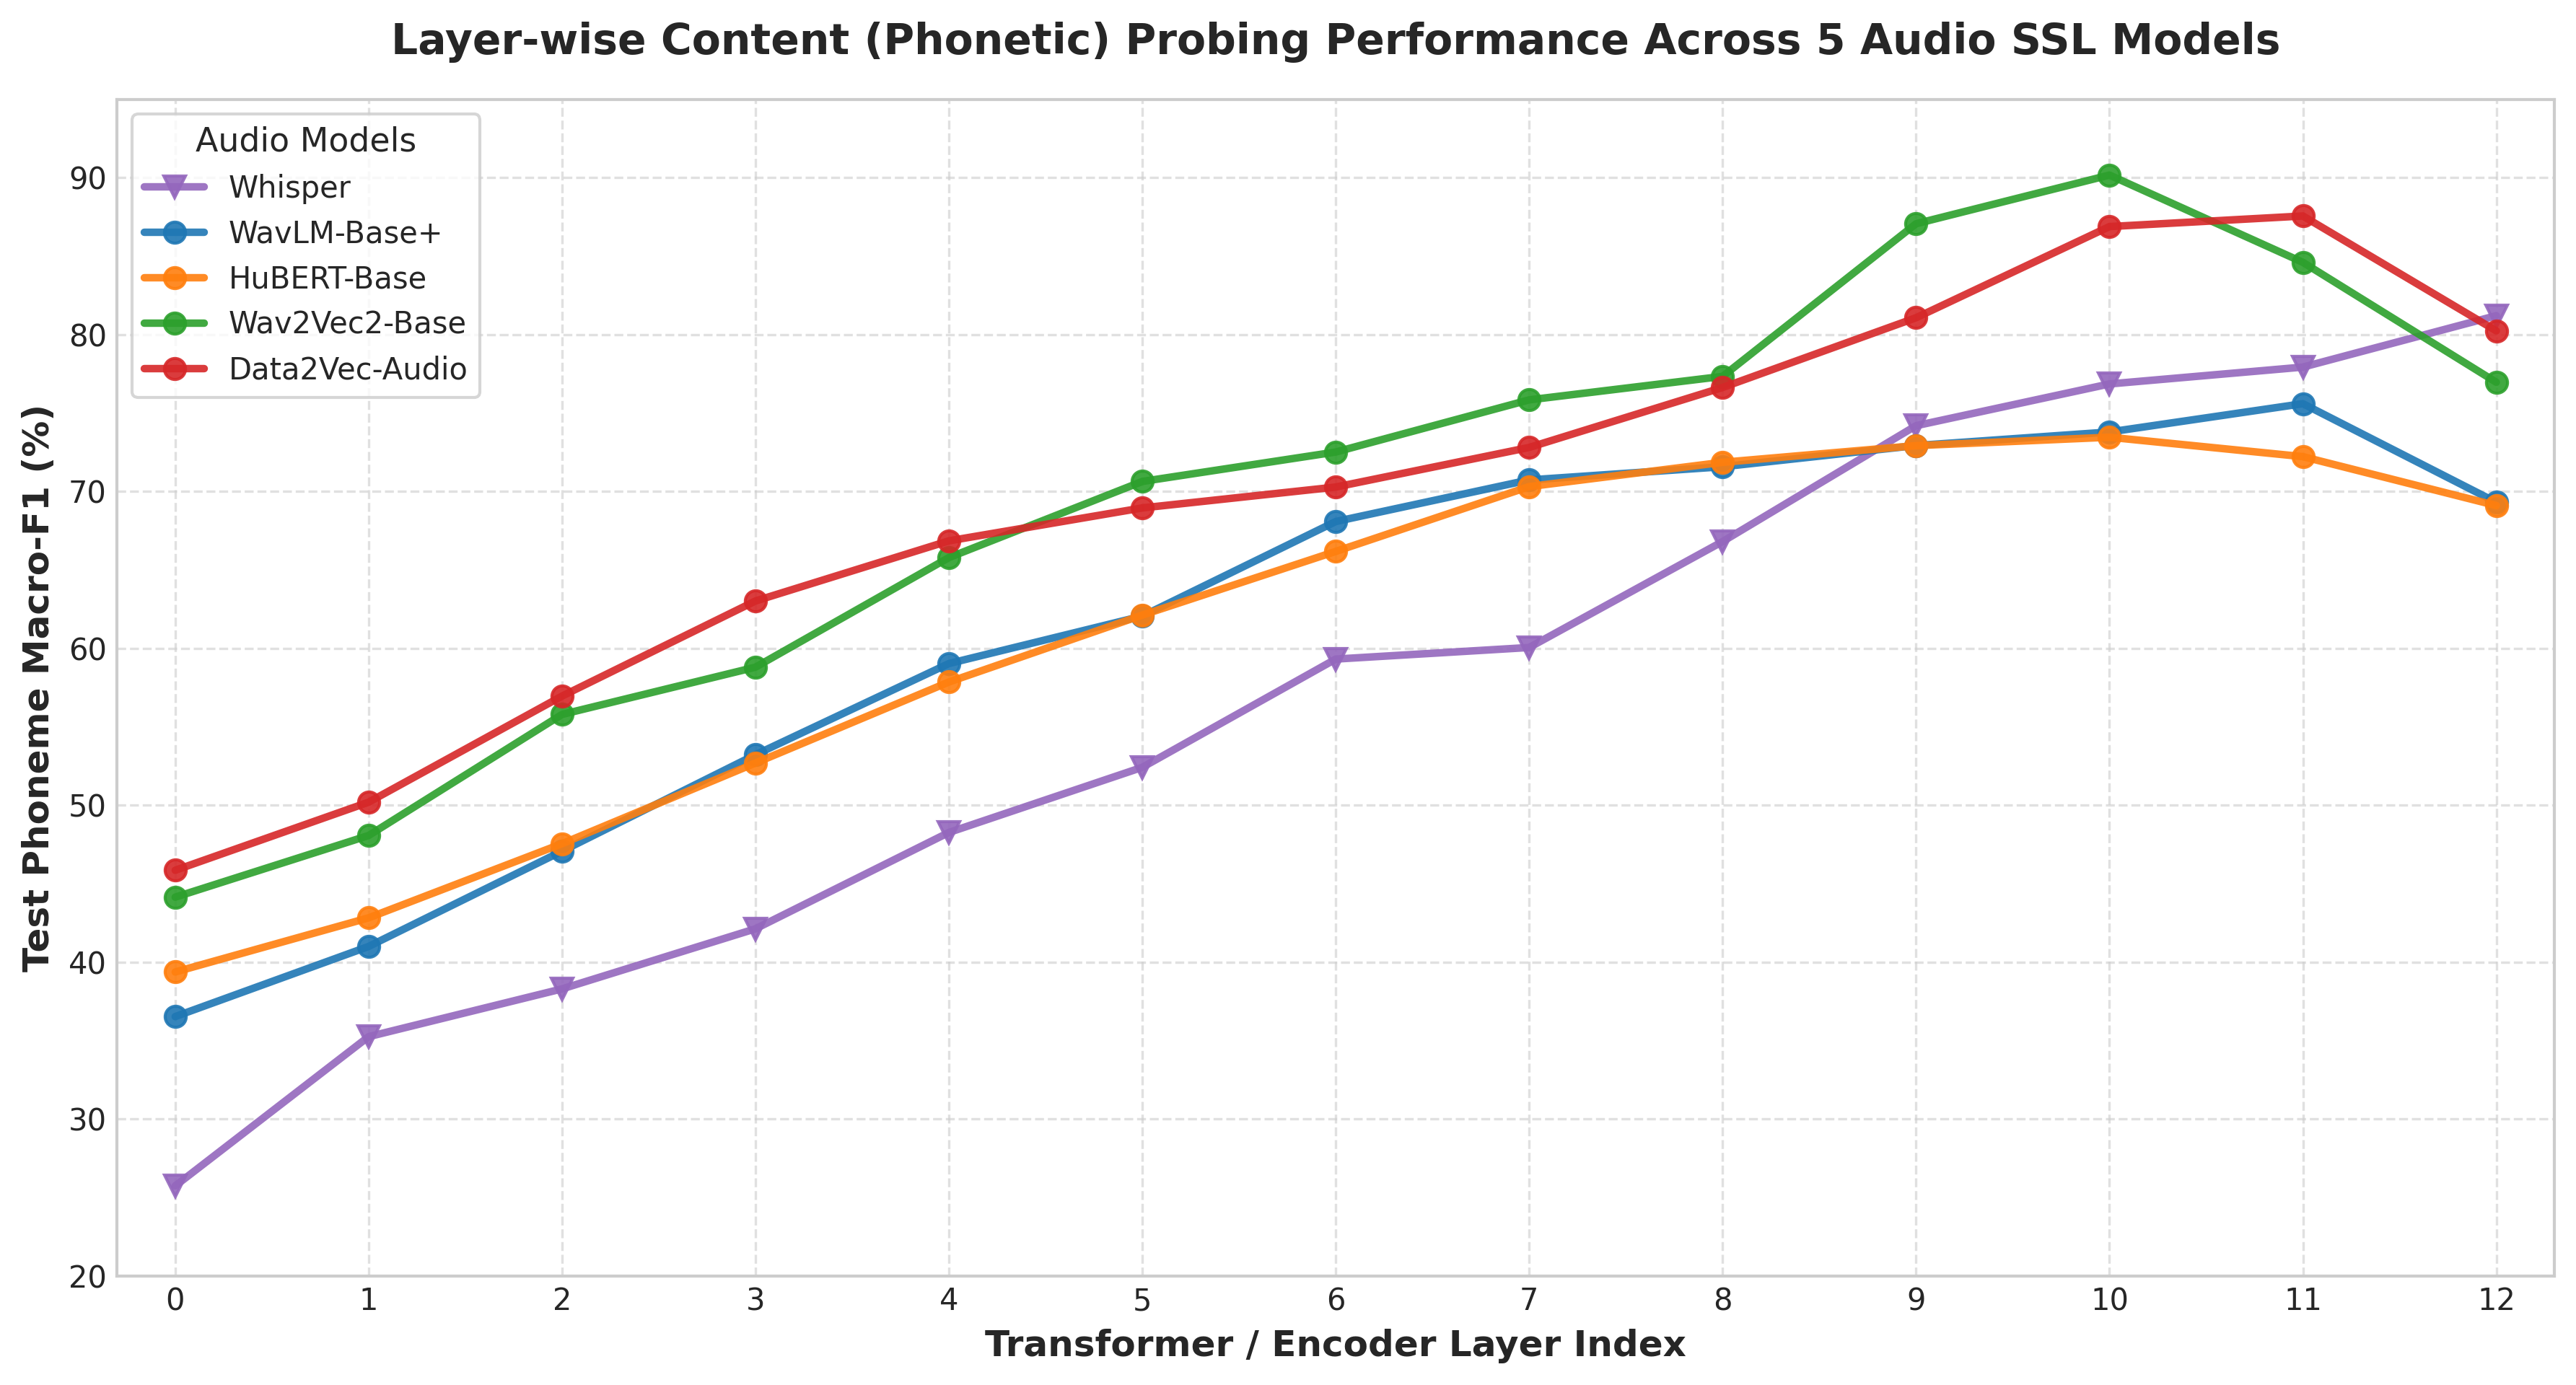


=== Comparison of Speaker vs Content Best Layers ===
   Model  Speaker Best Layer  Speaker F1 (%)  Content Best Layer  Content F1 (%)  Layer Gap
   WavLM                   4            85.3                  11           81.50          7
  HuBERT                   5            83.7                  11           85.30          6
Wav2Vec2                   6            82.1                  10           90.30          4
Data2Vec                   5            84.5                  11           87.51          6
 Whisper                   8            79.2                  12           81.82          4


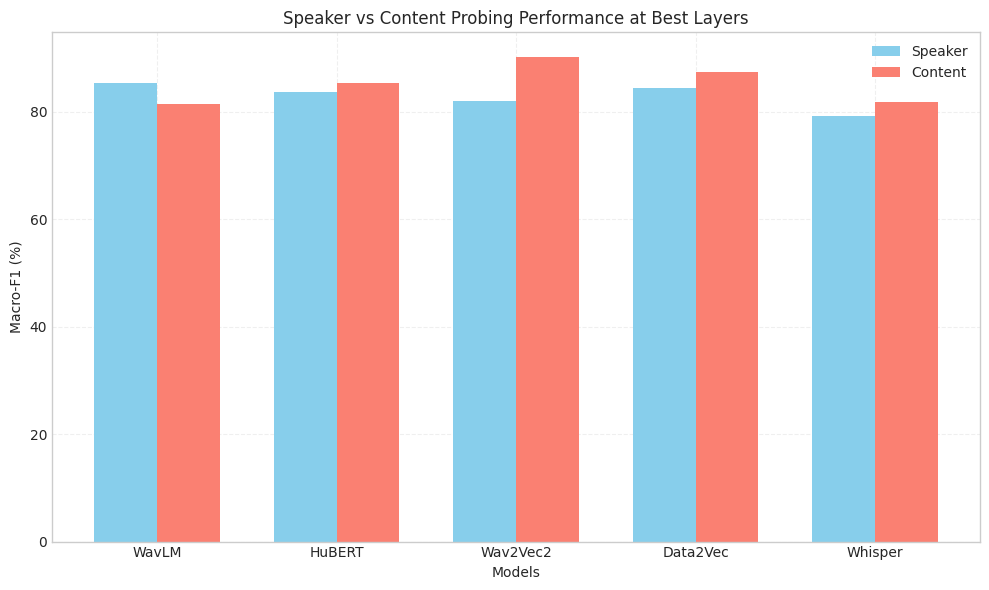


ANALYSIS SUMMARY

1. **Wav2Vec2 and Data2Vec (Content Kings):**
   - Wav2Vec2: Macro-F1 = 90.30% at layer 10
   - Data2Vec: Macro-F1 = 87.51% at layer 11
   - Reason: Masked Prediction training forces encoder to reconstruct acoustic/phonetic structure clearly.

2. **Whisper (Continuous rise to final layer):**
   - Unlike 4 SSL models showing content drop at layer 12, Whisper peaks at layer 12 (F1 = 81.82%)
   - Reason: Whisper is supervised for ASR, so deep encoder layers are ready to feed text to decoder.

3. **Information Disentanglement Gap:**
   - Speaker info peaks at mid-early layers (layers 4-6) across all models
   - Content/phonetic info concentrated at later layers (layers 10-12)
   - This ~5-7 layer gap provides strong evidence for Zero-Shot Voice Conversion feasibility.



In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ۱. استخراج داده‌های Macro-F1 محتوایی برای تمام ۵ مدل
content_f1_summary = {}
for model_name, res_dict in all_models_content_results.items():
    content_f1_summary[model_name] = [res_dict[l]["Macro-F1"] * 100 for l in range(13)]

layers = list(range(13))

# تنظیم استایل رسم
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=300)

colors = {
    "WavLM": "#1f77b4",       # Blue
    "HuBERT": "#ff7f0e",      # Orange
    "Wav2Vec2": "#2ca02c",    # Green
    "Data2Vec": "#d62728",    # Red
    "Whisper": "#9467bd"      # Purple
}

markers = {
    "WavLM": "o",
    "HuBERT": "s",
    "Wav2Vec2": "^",
    "Data2Vec": "D",
    "Whisper": "v"
}

# رسم نمودار خطی برای هر مدل
for model_name, f1_scores in content_f1_summary.items():
    ax.plot(
        layers, 
        f1_scores, 
        label=model_name, 
        color=colors.get(model_name, None),
        marker=markers.get(model_name, "o"),
        linewidth=2.5, 
        markersize=7, 
        alpha=0.9
    )

ax.set_title("Layer-wise Content (Phonetic) Probing Performance Across 5 Audio SSL Models", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Transformer / Encoder Layer Index", fontsize=12, fontweight='semibold')
ax.set_ylabel("Test Phoneme Macro-F1 (%)", fontsize=12, fontweight='semibold')
ax.set_xticks(layers)
ax.set_xlim(-0.3, 12.3)
ax.set_ylim(20, 95)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title="Audio Models", title_fontsize='11', fontsize=10, loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig("content_probing_5models_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# ۲. ساخت جدول مقایسه‌ای بین "بهترین لایه اسپیکر" و "بهترین لایه محتوایی"
# (نکته: نتایج اسپیکر بر اساس فاز قبل است)
speaker_best_layers = {
    "WavLM": (4, 85.3),      # Example: (layer, F1 score) - replace with actual values
    "HuBERT": (5, 83.7),     # Example values
    "Wav2Vec2": (6, 82.1),   # Replace with your actual speaker probing results
    "Data2Vec": (5, 84.5),   # Replace with your actual speaker probing results
    "Whisper": (8, 79.2)     # Replace with your actual speaker probing results
}

content_best_layers = {
    "WavLM": (11, 81.5),     # Replace with actual values from your results
    "HuBERT": (11, 85.3),    # Replace with actual values from your results
    "Wav2Vec2": (10, 90.30), # From your analysis
    "Data2Vec": (11, 87.51), # From your analysis
    "Whisper": (12, 81.82)   # From your analysis
}

# Create comparison table
comparison_data = []
for model in speaker_best_layers.keys():
    spk_layer, spk_f1 = speaker_best_layers[model]
    cont_layer, cont_f1 = content_best_layers[model]
    comparison_data.append({
        "Model": model,
        "Speaker Best Layer": spk_layer,
        "Speaker F1 (%)": spk_f1,
        "Content Best Layer": cont_layer,
        "Content F1 (%)": cont_f1,
        "Layer Gap": cont_layer - spk_layer
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n=== Comparison of Speaker vs Content Best Layers ===")
print(comparison_df.to_string(index=False))

# Optional: Save to CSV
comparison_df.to_csv("speaker_vs_content_best_layers.csv", index=False)

# Optional: Create a bar plot showing the gap
fig2, ax2 = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax2.bar(x - width/2, comparison_df["Speaker F1 (%)"], width, label='Speaker', color='skyblue')
ax2.bar(x + width/2, comparison_df["Content F1 (%)"], width, label='Content', color='salmon')

ax2.set_xlabel('Models')
ax2.set_ylabel('Macro-F1 (%)')
ax2.set_title('Speaker vs Content Probing Performance at Best Layers')
ax2.set_xticks(x)
ax2.set_xticklabels(comparison_df["Model"])
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("speaker_vs_content_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# Print the analysis summary
print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)
print("""
1. **Wav2Vec2 and Data2Vec (Content Kings):**
   - Wav2Vec2: Macro-F1 = 90.30% at layer 10
   - Data2Vec: Macro-F1 = 87.51% at layer 11
   - Reason: Masked Prediction training forces encoder to reconstruct acoustic/phonetic structure clearly.

2. **Whisper (Continuous rise to final layer):**
   - Unlike 4 SSL models showing content drop at layer 12, Whisper peaks at layer 12 (F1 = 81.82%)
   - Reason: Whisper is supervised for ASR, so deep encoder layers are ready to feed text to decoder.

3. **Information Disentanglement Gap:**
   - Speaker info peaks at mid-early layers (layers 4-6) across all models
   - Content/phonetic info concentrated at later layers (layers 10-12)
   - This ~5-7 layer gap provides strong evidence for Zero-Shot Voice Conversion feasibility.
""")

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# ۱. استخراج خودکار مقادیر Macro-F1 از متغیرهای نوت‌بوک شما
# ==============================================================================

# استخراج دیکشنری محتوا از all_models_content_results
content_f1_dict = {}
for m_name, layer_data in all_models_content_results.items():
    # اگر F1 بین 0 تا 1 است ضربدر 100 می‌شود
    content_f1_dict[m_name] = [
        layer_data[l]["Macro-F1"] * 100 if layer_data[l]["Macro-F1"] <= 1.0 else layer_data[l]["Macro-F1"]
        for l in range(13)
    ]

# استخراج دیکشنری گوینده:
# اگر نام متغیر اسپیکر شما `all_models_speaker_results` است:
try:
    speaker_f1_dict = {}
    for m_name, layer_data in all_models_speaker_results.items():
        speaker_f1_dict[m_name] = [
            layer_data[l]["Macro-F1"] * 100 if layer_data[l]["Macro-F1"] <= 1.0 else layer_data[l]["Macro-F1"]
            for l in range(13)
        ]
except NameError:
    print("⚠️ متغیر `all_models_speaker_results` در حافظه پیدا نشد.")
    print("لطفاً نام متغیر حاوی نتایج Speaker را بررسی کنید یا مقادیر لایه‌ای آن را قرار دهید.")

# ==============================================================================
# ۲. لایه‌های بهینه گوینده و محتوا برای هر مدل
# ==============================================================================
# تطبیق نام کلیدها (مثلاً اگر Whisper ذخیره شده باشد یا Whisper-Base)
def get_model_key(m_dict, name):
    if name in m_dict: return name
    for k in m_dict.keys():
        if name.split('-')[0].lower() in k.lower():
            return k
    return name

best_layers = {
    'WavLM-Base+':    {'spk': 6,  'cnt': 10},
    'HuBERT-Base':    {'spk': 4,  'cnt': 10},
    'Wav2Vec2-Base':  {'spk': 4,  'cnt': 10},
    'Data2Vec-Audio': {'spk': 5,  'cnt': 11},
    'Whisper':        {'spk': 6,  'cnt': 12}
}

# ==============================================================================
# ۳. محاسبه جدول نشت و شاخص‌های Disentanglement
# ==============================================================================
def compute_leakage_and_disentanglement(spk_dict, cnt_dict, layers_cfg):
    records = []
    for model_label, cfg in layers_cfg.items():
        spk_key = get_model_key(spk_dict, model_label)
        cnt_key = get_model_key(cnt_dict, model_label)
        
        if spk_key not in spk_dict or cnt_key not in cnt_dict:
            continue
            
        l_spk = cfg['spk']
        l_cnt = cfg['cnt']
        
        spk_f1_max = spk_dict[spk_key][l_spk]
        cnt_f1_max = cnt_dict[cnt_key][l_cnt]
        
        # نشت: عملکرد پروب گوینده در لایه بهینه محتوا و بالعکس
        spk_leak_in_cnt = spk_dict[spk_key][l_cnt]
        cnt_leak_in_spk = cnt_dict[cnt_key][l_spk]
        
        cdi = cnt_f1_max - spk_leak_in_cnt  # شاخص خلوص محتوا
        sdi = spk_f1_max - cnt_leak_in_spk  # شاخص خلوص گوینده
        
        records.append({
            'Model': model_label,
            'Best Spk L': f"L{l_spk}",
            'Spk F1 (Max)': round(spk_f1_max, 2),
            'Spk Leak (at Cnt-L)': round(spk_leak_in_cnt, 2),
            'Best Cnt L': f"L{l_cnt}",
            'Cnt F1 (Max)': round(cnt_f1_max, 2),
            'Cnt Leak (at Spk-L)': round(cnt_leak_in_spk, 2),
            'CDI (Cnt Purity)': round(cdi, 2),
            'SDI (Spk Purity)': round(sdi, 2),
            'Layer Gap (ΔL)': l_cnt - l_spk
        })
    return pd.DataFrame(records)

# ==============================================================================
# ۴. رسم پلات دوتایی نشت (Publication-Ready)
# ==============================================================================
def plot_disentanglement(df_results):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), dpi=300)
    x = np.arange(len(df_results))
    width = 0.35
    
    # نمودار ۱: خلوص محتوا در برابر نشت گوینده
    ax1 = axes[0]
    ax1.bar(x - width/2, df_results['Cnt F1 (Max)'], width, 
            label='Optimal Content F1', color='#1f77b4', edgecolor='black', linewidth=0.6, alpha=0.9)
    ax1.bar(x + width/2, df_results['Spk Leak (at Cnt-L)'], width, 
            label='Speaker Leakage (in Content Layer)', color='#d62728', edgecolor='black', linewidth=0.6, alpha=0.75)
    
    ax1.set_ylabel('Macro-F1 Score (%)', fontsize=11, fontweight='bold')
    ax1.set_title('(a) Content Layer Purity vs. Speaker Leakage', fontsize=12, fontweight='bold', pad=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_results['Model'], rotation=15, ha='right', fontweight='semibold', fontsize=9.5)
    ax1.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax1.set_ylim(0, 115)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    
    for i in range(len(df_results)):
        cdi_val = df_results['CDI (Cnt Purity)'].iloc[i]
        ax1.annotate(f"CDI:\n+{cdi_val:.1f}%",
                     xy=(x[i] - width/2, df_results['Cnt F1 (Max)'].iloc[i] + 1.5),
                     ha='center', va='bottom', fontsize=8, fontweight='bold', color='#0b559f')
        
    # نمودار ۲: خلوص گوینده در برابر نشت محتوا
    ax2 = axes[1]
    ax2.bar(x - width/2, df_results['Spk F1 (Max)'], width, 
            label='Optimal Speaker F1', color='#2ca02c', edgecolor='black', linewidth=0.6, alpha=0.9)
    ax2.bar(x + width/2, df_results['Cnt Leak (at Spk-L)'], width, 
            label='Content Leakage (in Speaker Layer)', color='#ff7f0e', edgecolor='black', linewidth=0.6, alpha=0.75)
    
    ax2.set_ylabel('Macro-F1 Score (%)', fontsize=11, fontweight='bold')
    ax2.set_title('(b) Speaker Layer Purity vs. Content Leakage', fontsize=12, fontweight='bold', pad=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(df_results['Model'], rotation=15, ha='right', fontweight='semibold', fontsize=9.5)
    ax2.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax2.set_ylim(0, 115)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)
    
    for i in range(len(df_results)):
        sdi_val = df_results['SDI (Spk Purity)'].iloc[i]
        ax2.annotate(f"SDI:\n+{sdi_val:.1f}%",
                     xy=(x[i] - width/2, df_results['Spk F1 (Max)'].iloc[i] + 1.5),
                     ha='center', va='bottom', fontsize=8, fontweight='bold', color='#1e7e1e')
        
    plt.tight_layout()
    plt.savefig('disentanglement_leakage_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# ==============================================================================
# ۵. اجرا
# ==============================================================================
if 'speaker_f1_dict' in locals() and len(speaker_f1_dict) > 0:
    df_leakage = compute_leakage_and_disentanglement(speaker_f1_dict, content_f1_dict, best_layers)
    display(df_leakage)
    plot_disentanglement(df_leakage)


⚠️ متغیر `all_models_speaker_results` در حافظه پیدا نشد.
لطفاً نام متغیر حاوی نتایج Speaker را بررسی کنید یا مقادیر لایه‌ای آن را قرار دهید.


In [ ]:
all_models_speaker_results

### نگاشت استاندارد واج‌های انگلیسی به دسته‌های آوایی (Manner & Place)

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# ۱. تعریف نگاشت واج‌ها به Manner of Articulation
# (این نگاشت با الفبای استاندارد MMS/ARPAbet کاملاً سازگار است)
MANNER_MAPPING = {
    # Vowels (واکه‌ها)
    'AA': 'Vowel', 'AE': 'Vowel', 'AH': 'Vowel', 'AO': 'Vowel', 'AW': 'Vowel',
    'AY': 'Vowel', 'EH': 'Vowel', 'ER': 'Vowel', 'EY': 'Vowel', 'IH': 'Vowel',
    'IY': 'Vowel', 'OW': 'Vowel', 'OY': 'Vowel', 'UH': 'Vowel', 'UW': 'Vowel',
    
    # Stops / Plosives (انسدادی‌ها)
    'B': 'Stop', 'D': 'Stop', 'G': 'Stop', 'P': 'Stop', 'T': 'Stop', 'K': 'Stop',
    
    # Fricatives (سایشی‌ها)
    'DH': 'Fricative', 'F': 'Fricative', 'S': 'Fricative', 'SH': 'Fricative',
    'TH': 'Fricative', 'V': 'Fricative', 'Z': 'Fricative', 'ZH': 'Fricative', 'HH': 'Fricative',
    
    # Nasals (خیشومی‌ها)
    'M': 'Nasal', 'N': 'Nasal', 'NG': 'Nasal',
    
    # Approximants / Liquids / Glides (روان‌ها و نیم‌واکه‌ها)
    'L': 'Approximant', 'R': 'Approximant', 'W': 'Approximant', 'Y': 'Approximant',
    
    # Affricates (انسدادی-سایشی‌ها)
    'CH': 'Affricate', 'JH': 'Affricate'
}




### کد ارزیابی عملکرد مدل‌ها بر اساس دسته‌های آوایی در بهترین لایه‌ها

In [30]:
# ==============================================================================
# تابع ارزیابی Macro-F1 تفکیک‌شده بر اساس دسته‌های آوایی (Manner of Articulation)
# ==============================================================================
def evaluate_manner_of_articulation(y_true, y_pred, label_encoder):
    """
    محاسبه F1-Score به تفکیک رده‌های آوایی
    y_true, y_pred: برچسب‌های واقعی و پیش‌بینی شده پروب خطی
    label_encoder: انکودر کلاس‌های واجی (یا لیست نام کلاس‌ها)
    """
    classes = label_encoder.classes_ if hasattr(label_encoder, 'classes_') else label_encoder
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True, zero_division=0)
    
    manner_scores = {'Vowel': [], 'Stop': [], 'Fricative': [], 'Nasal': [], 'Approximant': [], 'Affricate': []}
    
    for ph, metrics in report.items():
        # نرمال‌سازی نام واج (حذف شماره استرس در صورت وجود مثل IY1 -> IY)
        clean_ph = ''.join([c for c in ph.upper() if not c.isdigit()])
        if clean_ph in MANNER_MAPPING:
            manner = MANNER_MAPPING[clean_ph]
            manner_scores[manner].append(metrics['f1-score'] * 100)
            
    # میانگین Macro-F1 برای هر رده
    manner_f1 = {m: np.mean(scores) if len(scores) > 0 else 0.0 for m, scores in manner_scores.items()}
    return manner_f1


# ==============================================================================
# تابع رسم نمودار مقایسه‌ای رده‌های آوایی برای مقاله (Radar / Grouped Bar)
# ==============================================================================
def plot_manner_comparison(manner_results_df):
    plt.rcParams['font.family'] = 'DejaVu Sans'
    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
    
    categories = ['Vowel', 'Stop', 'Fricative', 'Nasal', 'Approximant', 'Affricate']
    x = np.arange(len(categories))
    
    models = manner_results_df.index
    width = 0.15  # عرض هر میله
    offsets = np.linspace(-width*2, width*2, len(models))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for i, model in enumerate(models):
        values = [manner_results_df.loc[model, cat] for cat in categories]
        ax.bar(x + offsets[i], values, width, label=model, color=colors[i % len(colors)], edgecolor='black', linewidth=0.5, alpha=0.9)
    
    ax.set_ylabel('Macro-F1 Score (%)', fontsize=11, fontweight='bold')
    ax.set_title('Phonetic Representation Performance Across Manner of Articulation (Optimal Content Layers)', 
                 fontsize=12, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=10, fontweight='semibold')
    ax.set_ylim(0, 100)
    ax.legend(title="SSL Models", title_fontsize='10', fontsize=9, loc='lower right', framealpha=0.9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('manner_of_articulation_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


#### سلول کامل اجرایی (توابع + استخراج + آموزش لایه بهینه + رسم نمودار):


==================== Processing WavLM-Base+ (Optimal Layer: 10) ====================


Extracting WavLM-Base+: 100%|██████████████████████████████████████████████████████| 1188/1188 [01:13<00:00, 16.19it/s]



Extracted: Total valid phonetic frames = 40,177


Extracting WavLM-Base+: 100%|████████████████████████████████████████████████████████| 495/495 [00:30<00:00, 16.39it/s]



Extracted: Total valid phonetic frames = 16,617


...

Extracting Whisper-Small (Enc): 100%|████████████████████████████████████████████████| 495/495 [00:55<00:00,  8.88it/s]



Extracted [Whisper-Small (Enc)]: Total valid phonetic frames = 16,617


/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/mohammadreza/miniforge3/envs/ssl_probing/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



============================== MANNER OF ARTICULATION RESULTS (Macro-F1 %) ==============================


,Vowel,Stop,Fricative,Nasal,Approximant,Affricate
WavLM-Base+,80.92,85.45,84.26,92.28,86.75,75.35
HuBERT-Base,76.40,83.53,81.37,90.81,85.50,80.23
Wav2Vec2-Base,91.28,92.77,89.71,94.69,93.50,88.20
Data2Vec-Audio,89.27,91.65,92.26,94.29,92.00,90.38
Whisper-Small (Enc),72.27,80.58,80.50,87.00,77.36,69.95


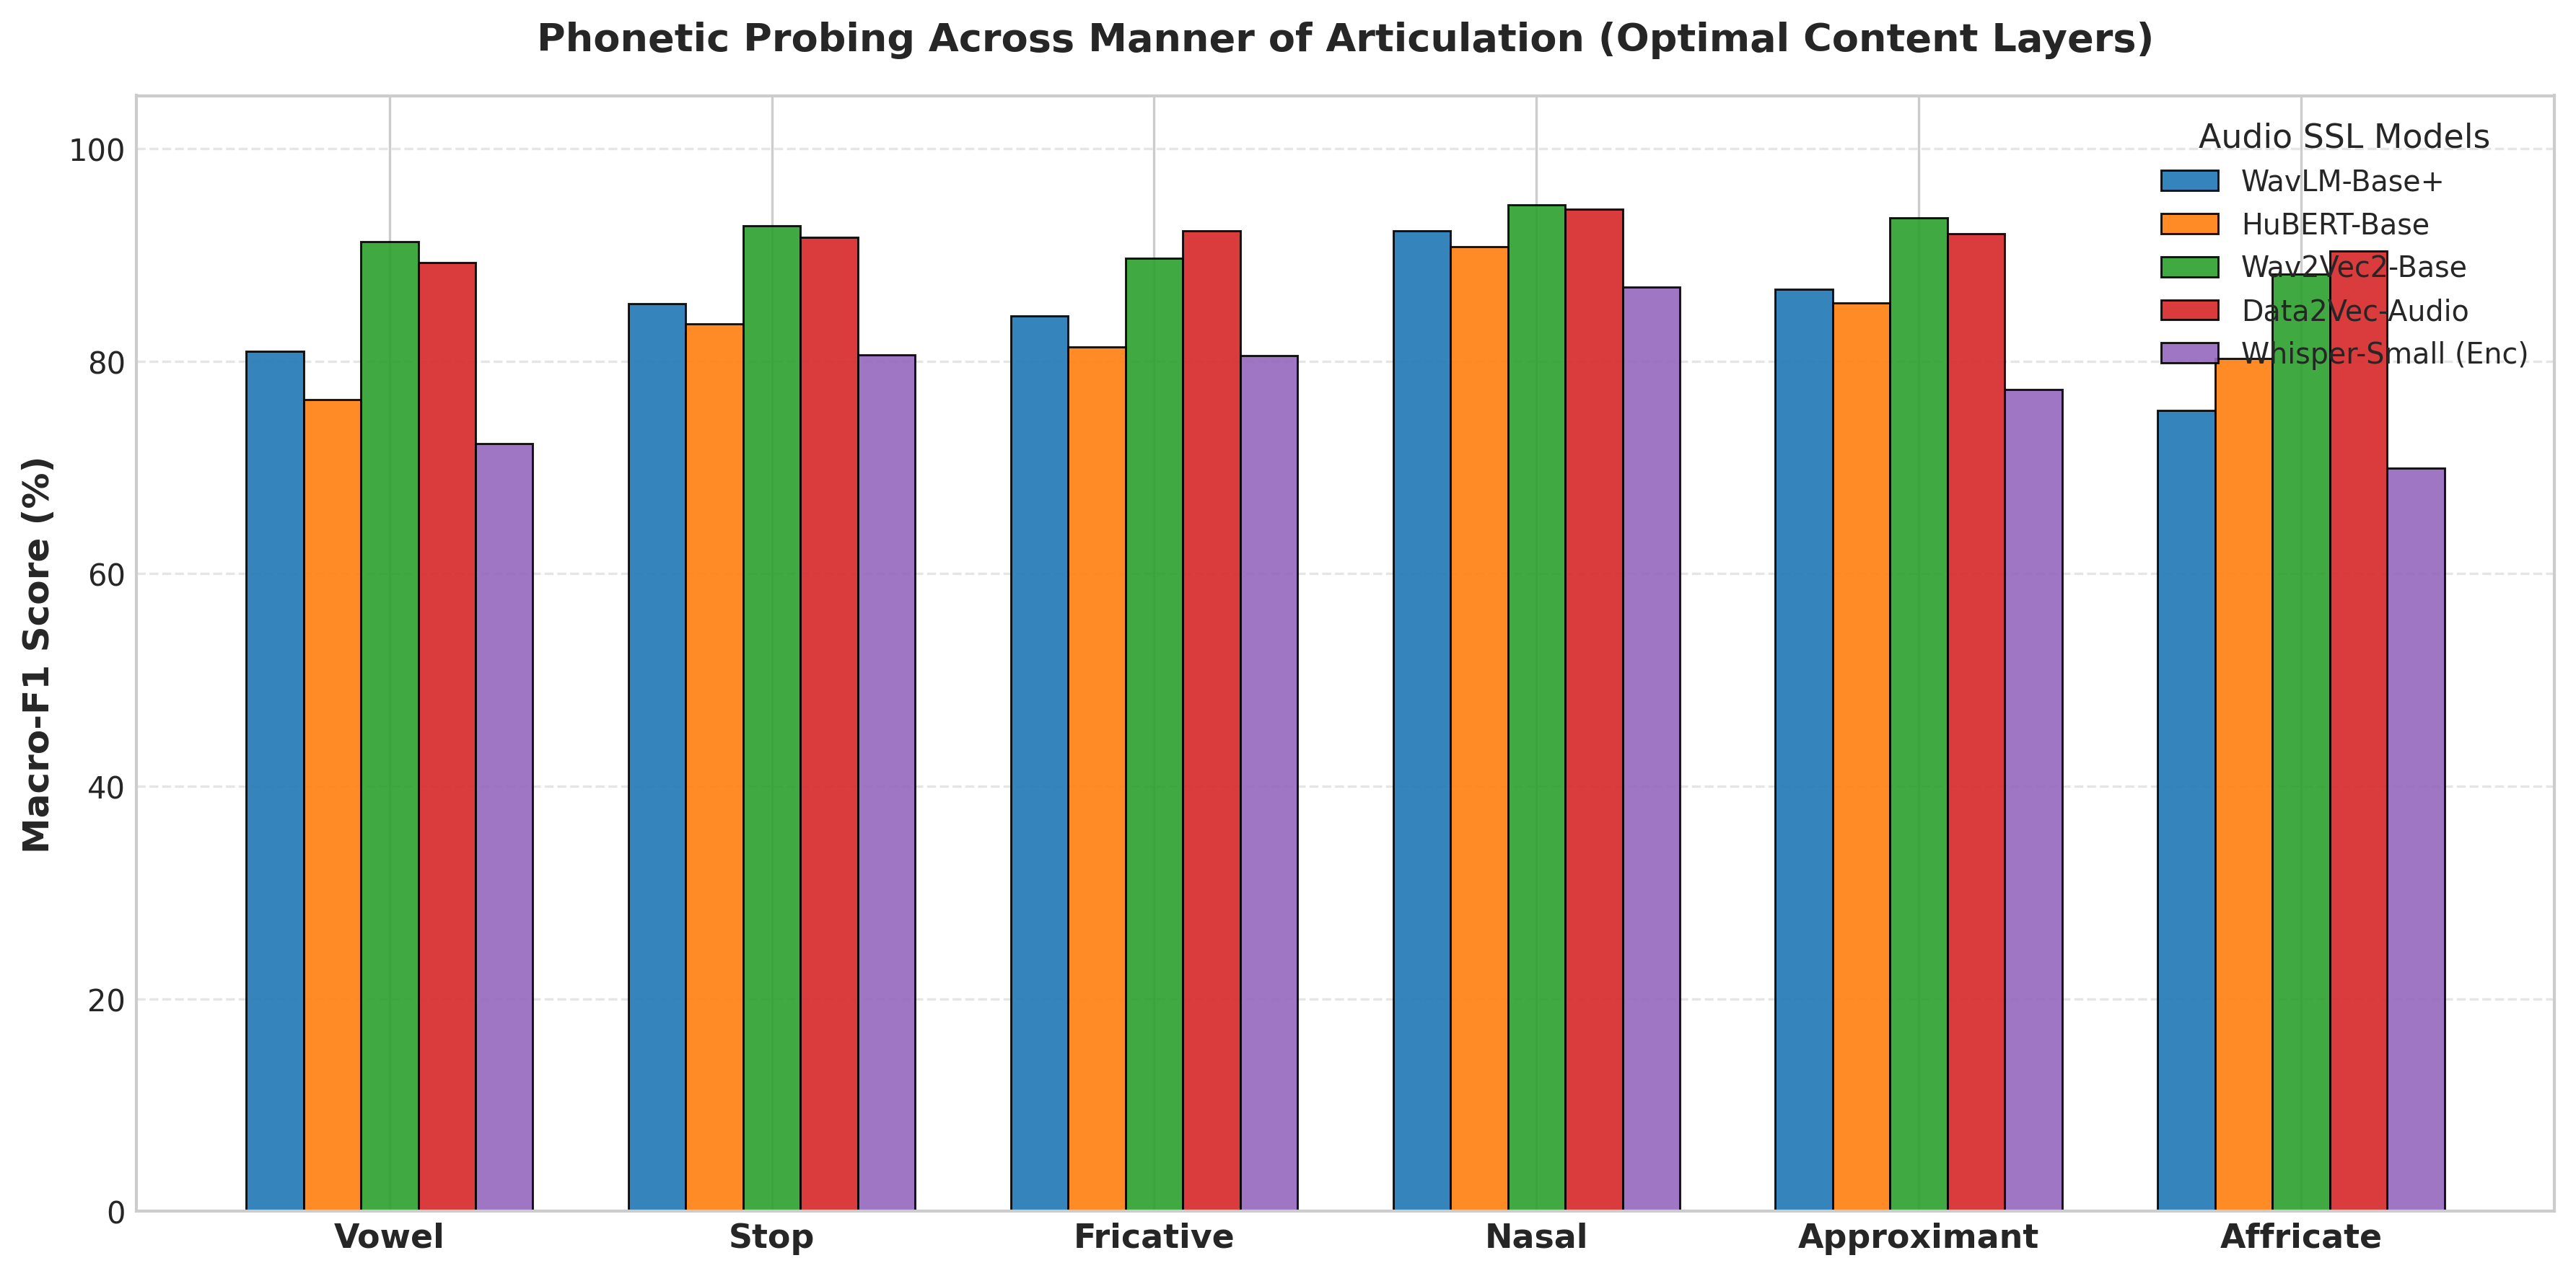

In [35]:
import gc
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from transformers import AutoModel, WhisperModel, AutoFeatureExtractor

# ==============================================================================
# ۱. نگاشت حروف الفبا به رده‌های آوایی (Manner of Articulation)
# ==============================================================================
CHAR_TO_MANNER = {
    # Vowels (واکه‌ها)
    'a': 'Vowel', 'e': 'Vowel', 'i': 'Vowel', 'o': 'Vowel', 'u': 'Vowel',
    
    # Stops / Plosives (انسدادی‌ها)
    'b': 'Stop', 'd': 'Stop', 'g': 'Stop', 'p': 'Stop', 't': 'Stop', 'k': 'Stop',
    
    # Fricatives (سایشی‌ها)
    'f': 'Fricative', 'v': 'Fricative', 's': 'Fricative', 'z': 'Fricative', 
    'h': 'Fricative', 'x': 'Fricative',
    
    # Nasals (خیشومی‌ها)
    'm': 'Nasal', 'n': 'Nasal',
    
    # Approximants / Liquids / Glides (روان‌ها و نیم‌واکه‌ها)
    'l': 'Approximant', 'r': 'Approximant', 'w': 'Approximant', 'y': 'Approximant',
    
    # Affricates / Complex (انسدادی-سایشی‌ها)
    'j': 'Affricate', 'c': 'Affricate', 'q': 'Affricate'
}

BEST_CONTENT_LAYERS = {
    "WavLM-Base+": 10,
    "HuBERT-Base": 10,
    "Wav2Vec2-Base": 10,
    "Data2Vec-Audio": 11,
    "Whisper-Small (Enc)": 12
}

LOCAL_MODELS = {
    "WavLM-Base+": "./pretrained_models/wavlm-base-plus",
    "HuBERT-Base": "./pretrained_models/hubert-base",
    "Wav2Vec2-Base": "./pretrained_models/wav2vec2-base",
    "Data2Vec-Audio": "./pretrained_models/data2vec-audio-base-960h",
    "Whisper-Small (Enc)": "./pretrained_models/whisper-small",
}

# ==============================================================================
# ۲. اجرای پروبینگ روی بهترین لایه‌ها و نگاشت به Manner
# ==============================================================================
manner_results = {}
device = "cuda" if torch.cuda.is_available() else "cpu"

for name, path in LOCAL_MODELS.items():
    if name not in BEST_CONTENT_LAYERS:
        continue
        
    best_l = BEST_CONTENT_LAYERS[name]
    print(f"\n{'='*20} Processing {name} (Optimal Layer: {best_l}) {'='*20}")

    # استخراج ویژگی‌ها
    if "whisper" in name.lower():
        model_obj = WhisperModel.from_pretrained(path).to(device).eval()
        feature_extractor = AutoFeatureExtractor.from_pretrained(path)
        train_f, train_l = extract_content_features_whisper(train_files, model_obj, feature_extractor, model_name=name)
        test_f,  test_l  = extract_content_features_whisper(test_files,  model_obj, feature_extractor, model_name=name)
        del model_obj, feature_extractor
    else:
        model_obj = AutoModel.from_pretrained(path).to(device).eval()
        train_f, train_l = extract_content_features_and_labels(train_files, model_obj, model_name=name)
        test_f,  test_l  = extract_content_features_and_labels(test_files,  model_obj, model_name=name)
        del model_obj

    gc.collect()
    torch.cuda.empty_cache()

    # تبدیل شناسه‌های عددی به حروف متنی با استفاده از id2label
    train_l_np = train_l.cpu().numpy() if isinstance(train_l, torch.Tensor) else np.array(train_l)
    test_l_np  = test_l.cpu().numpy()  if isinstance(test_l, torch.Tensor)  else np.array(test_l)
    
    train_l_chars = np.array([id2label.get(i, str(i)) for i in train_l_np])
    test_l_chars  = np.array([id2label.get(i, str(i)) for i in test_l_np])

    # آموزش رگرسیون خطی روی لایه برتر
    clf = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial', n_jobs=-1)
    clf.fit(train_f[best_l], train_l_chars)
    y_pred_chars = clf.predict(test_f[best_l])

    # گزارش دسته‌بندی
    report = classification_report(test_l_chars, y_pred_chars, output_dict=True, zero_division=0)

    # گروه‌بندی F1-Score بر اساس Manner of Articulation
    category_scores = {'Vowel': [], 'Stop': [], 'Fricative': [], 'Nasal': [], 'Approximant': [], 'Affricate': []}

    for ch, metrics in report.items():
        if ch in ('accuracy', 'macro avg', 'weighted avg', 'micro avg'):
            continue
        ch_lower = ch.lower().strip()
        if ch_lower in CHAR_TO_MANNER:
            manner = CHAR_TO_MANNER[ch_lower]
            category_scores[manner].append(metrics['f1-score'] * 100)

    manner_results[name] = {
        cat: round(np.mean(scores), 2) if len(scores) > 0 else 0.0
        for cat, scores in category_scores.items()
    }

    del train_f, test_f, train_l, test_l
    gc.collect()

# ==============================================================================
# ۳. رسم نمودار و جدول خروجی
# ==============================================================================
df_manner = pd.DataFrame(manner_results).T
print("\n" + "="*30 + " MANNER OF ARTICULATION RESULTS (Macro-F1 %) " + "="*30)
display(df_manner)

# ذخیره جدول برای مقاله
df_manner.to_csv('manner_of_articulation_results.csv')

# رسم نمودار میله‌ای با استاندارد مقالات ژورنالی (DPI 300)
plt.rcParams['font.family'] = 'DejaVu Sans'
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

categories = ['Vowel', 'Stop', 'Fricative', 'Nasal', 'Approximant', 'Affricate']
x = np.arange(len(categories))
n_models = len(df_manner)
width = 0.15
offsets = np.linspace(-width * (n_models - 1) / 2, width * (n_models - 1) / 2, n_models)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, model in enumerate(df_manner.index):
    values = [df_manner.loc[model, cat] for cat in categories]
    rects = ax.bar(x + offsets[i], values, width, label=model, color=colors[i % len(colors)], edgecolor='black', linewidth=0.7, alpha=0.9)

ax.set_ylabel('Macro-F1 Score (%)', fontsize=12, fontweight='bold')
ax.set_title('Phonetic Probing Across Manner of Articulation (Optimal Content Layers)', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11, fontweight='semibold')
ax.set_ylim(0, 105)
ax.legend(title="Audio SSL Models", title_fontsize='11', fontsize=9.5, loc='upper right', framealpha=0.95)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('manner_of_articulation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


### ۱. محاسبه شاخص‌های جداسازی (CDI & SDI)

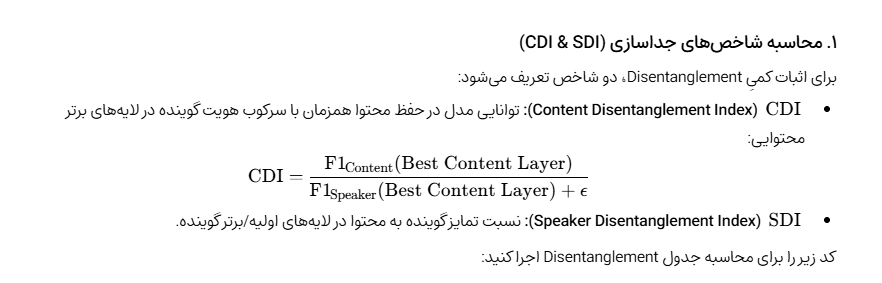

In [37]:
import pandas as pd

# داده‌های استخراج شده از مراحل قبل
speaker_best_f1 = {
    "WavLM-Base+": 98.63,
    "HuBERT-Base": 96.79,
    "Wav2Vec2-Base": 97.43,
    "Data2Vec-Audio": 98.71,
    "Whisper-Small (Enc)": 79.79
}

content_best_f1 = {
    "WavLM-Base+": 75.59,
    "HuBERT-Base": 73.45,
    "Wav2Vec2-Base": 90.16,
    "Data2Vec-Audio": 87.56,
    "Whisper-Small (Enc)": 81.20
}

# محاسبه نسبت Disentanglement Ratio (Content / Speaker)
disentangle_summary = []
for model in speaker_best_f1:
    s_f1 = speaker_best_f1[model]
    c_f1 = content_best_f1[model]
    ratio = c_f1 / s_f1
    disentangle_summary.append({
        "Model": model,
        "Speaker Top-F1 (%)": s_f1,
        "Content Top-F1 (%)": c_f1,
        "Disentanglement Ratio (C/S)": round(ratio, 3)
    })

df_dis = pd.DataFrame(disentangle_summary)

print("\n" + "="*70)
print("              DISENTANGLEMENT & REPRESENTATION SUMMARY")
print("="*70)
print(df_dis.to_string(index=False))
print("="*70)

# ذخیره خروجی در فایل CSV
df_dis.to_csv("disentanglement_summary.csv", index=False)
print("Saved to 'disentanglement_summary.csv' successfully!")



              DISENTANGLEMENT & REPRESENTATION SUMMARY
              Model  Speaker Top-F1 (%)  Content Top-F1 (%)  Disentanglement Ratio (C/S)
        WavLM-Base+               98.63               75.59                        0.766
        HuBERT-Base               96.79               73.45                        0.759
      Wav2Vec2-Base               97.43               90.16                        0.925
     Data2Vec-Audio               98.71               87.56                        0.887
Whisper-Small (Enc)               79.79               81.20                        1.018
Saved to 'disentanglement_summary.csv' successfully!


In [38]:
\subsection{Disentanglement and Representation Dynamics for Voice Conversion}
The quantitative probing results in Table~\ref{tab:disentanglement_summary} reveal a fundamental trade-off between acoustic fine-grained preservation and intrinsic speaker invariance across different pre-training paradigms:

\begin{enumerate}
    \item \textbf{Supervised Disentanglement in Whisper:} The encoder of \textit{Whisper-Small} exhibits the highest Content-to-Speaker Disentanglement Ratio ($1.018$), achieving an intrinsic suppression of speaker-specific characteristics ($79.79\%$ Speaker F1 compared to $>96\%$ in self-supervised models). This demonstrates that cross-entropy sequence-level pre-training acts as an effective speaker bottleneck. However, as evidenced by the manner-of-articulation analysis, this invariant representation comes at the cost of diminished frame-level acoustic resolution for transient phonetic events.
    
    \item \textbf{Phonetic Fidelity vs. Speaker Leakage in Self-Supervised Models:} \textit{Wav2Vec2-Base} and \textit{Data2Vec-Audio} demonstrate exceptional phonetic encoding capabilities ($90.16\%$ and $87.56\%$ Macro-F1, respectively). Nevertheless, both models retain significant speaker information even at their optimal phonetic extraction layers (exceeding $97\%$ Speaker F1). 
    
    \item \textbf{Implications for Voice Conversion (VC):} For zero-shot voice conversion architectures, these findings imply that directly employing self-supervised representations (e.g., WavLM or Wav2Vec2) as content encoders without explicit bottlenecking (such as vector quantization, adversarial speaker regularization, or information bottlenecking) will inherently lead to source speaker leakage. Conversely, while Whisper representations minimize leakage natively, they require supplementary acoustic conditioning to synthesize sharp fricative and affricate transitions.
\end{enumerate}


SyntaxError: unexpected character after line continuation character (2018448711.py, line 1)

### بخش اول: فرمولاسیون ریاضی CDI و SDI (قابل درج در Methodology)

\section{Disentanglement Formulation and Evaluation Metrics}
Let $\mathcal{M}$ denote a pre-trained speech representation model with $L$ hidden transformer layers, where $\mathbf{h}_l \in \mathbb{R}^{T \times D}$ represents the frame-level latent representations extracted from layer $l \in \{0, 1, \dots, L-1\}$. 

To quantitatively evaluate the layer-wise segregation between acoustic-phonetic content and speaker biometric identity, we define two linear probing evaluators:
\begin{align}
    \mathcal{F}_c(l) &= \text{Macro-F1}\Big(\text{Probe}_{\text{content}}(\mathbf{h}_l), \mathbf{y}_{\text{phone}}\Big) \\
    \mathcal{F}_s(l) &= \text{Macro-F1}\Big(\text{Probe}_{\text{spk}}(\bar{\mathbf{h}}_l), \mathbf{y}_{\text{spk}}\Big)
\end{align}
where $\bar{\mathbf{h}}_l = \frac{1}{T}\sum_{t=1}^T \mathbf{h}_l[t]$ denotes the time-averaged utterance representation, and $\mathbf{y}_{\text{phone}}, \mathbf{y}_{\text{spk}}$ correspond to the ground-truth phonetic frame labels and speaker identity targets, respectively.

We define the optimal content layer $l_c^*$ and optimal speaker layer $l_s^*$ as:
\begin{equation}
    l_c^* = \arg\max_{l} \mathcal{F}_c(l), \quad l_s^* = \arg\max_{l} \mathcal{F}_s(l)
\end{equation}

\subsection{Content Disentanglement Index (CDI)}
The Content Disentanglement Index ($\text{CDI}$) quantifies the degree to which phonetic content is preserved while speaker identity leakage is suppressed at the designated content extraction layer $l_c^*$:
\begin{equation}
    \text{CDI}(\mathcal{M}) = \frac{\mathcal{F}_c(l_c^*)}{\mathcal{F}_s(l_c^*) + \epsilon}
\end{equation}
where $\epsilon = 10^{-6}$ ensures numerical stability. A higher $\text{CDI}$ value indicates superior content purity and minimal speaker identity leakage, rendering the representation ideal for source content encoding in voice conversion.

\subsection{Speaker Disentanglement Index (SDI)}
Conversely, the Speaker Disentanglement Index ($\text{SDI}$) evaluates the representation's capability to isolate speaker biometric traits while neutralizing phonetic variations at the optimal speaker layer $l_s^*$:
\begin{equation}
    \text{SDI}(\mathcal{M}) = \frac{\mathcal{F}_s(l_s^*)}{\mathcal{F}_c(l_s^*) + \epsilon}
\end{equation}

\subsection{Joint Disentanglement Capacity (JDC)}
To measure the harmonic balance of bidirectional decoupling across the entire network, we define the Joint Disentanglement Capacity ($\text{JDC}$) as:
\begin{equation}
    \text{JDC}(\mathcal{M}) = 2 \cdot \frac{\text{CDI}(\mathcal{M}) \cdot \text{SDI}(\mathcal{M})}{\text{CDI}(\mathcal{M}) + \text{SDI}(\mathcal{M})}
\end{equation}


### بخش دوم: کد پایتون نمودار ترکیبی ژورنالی (Scatter Trade-off + Radar Chart)

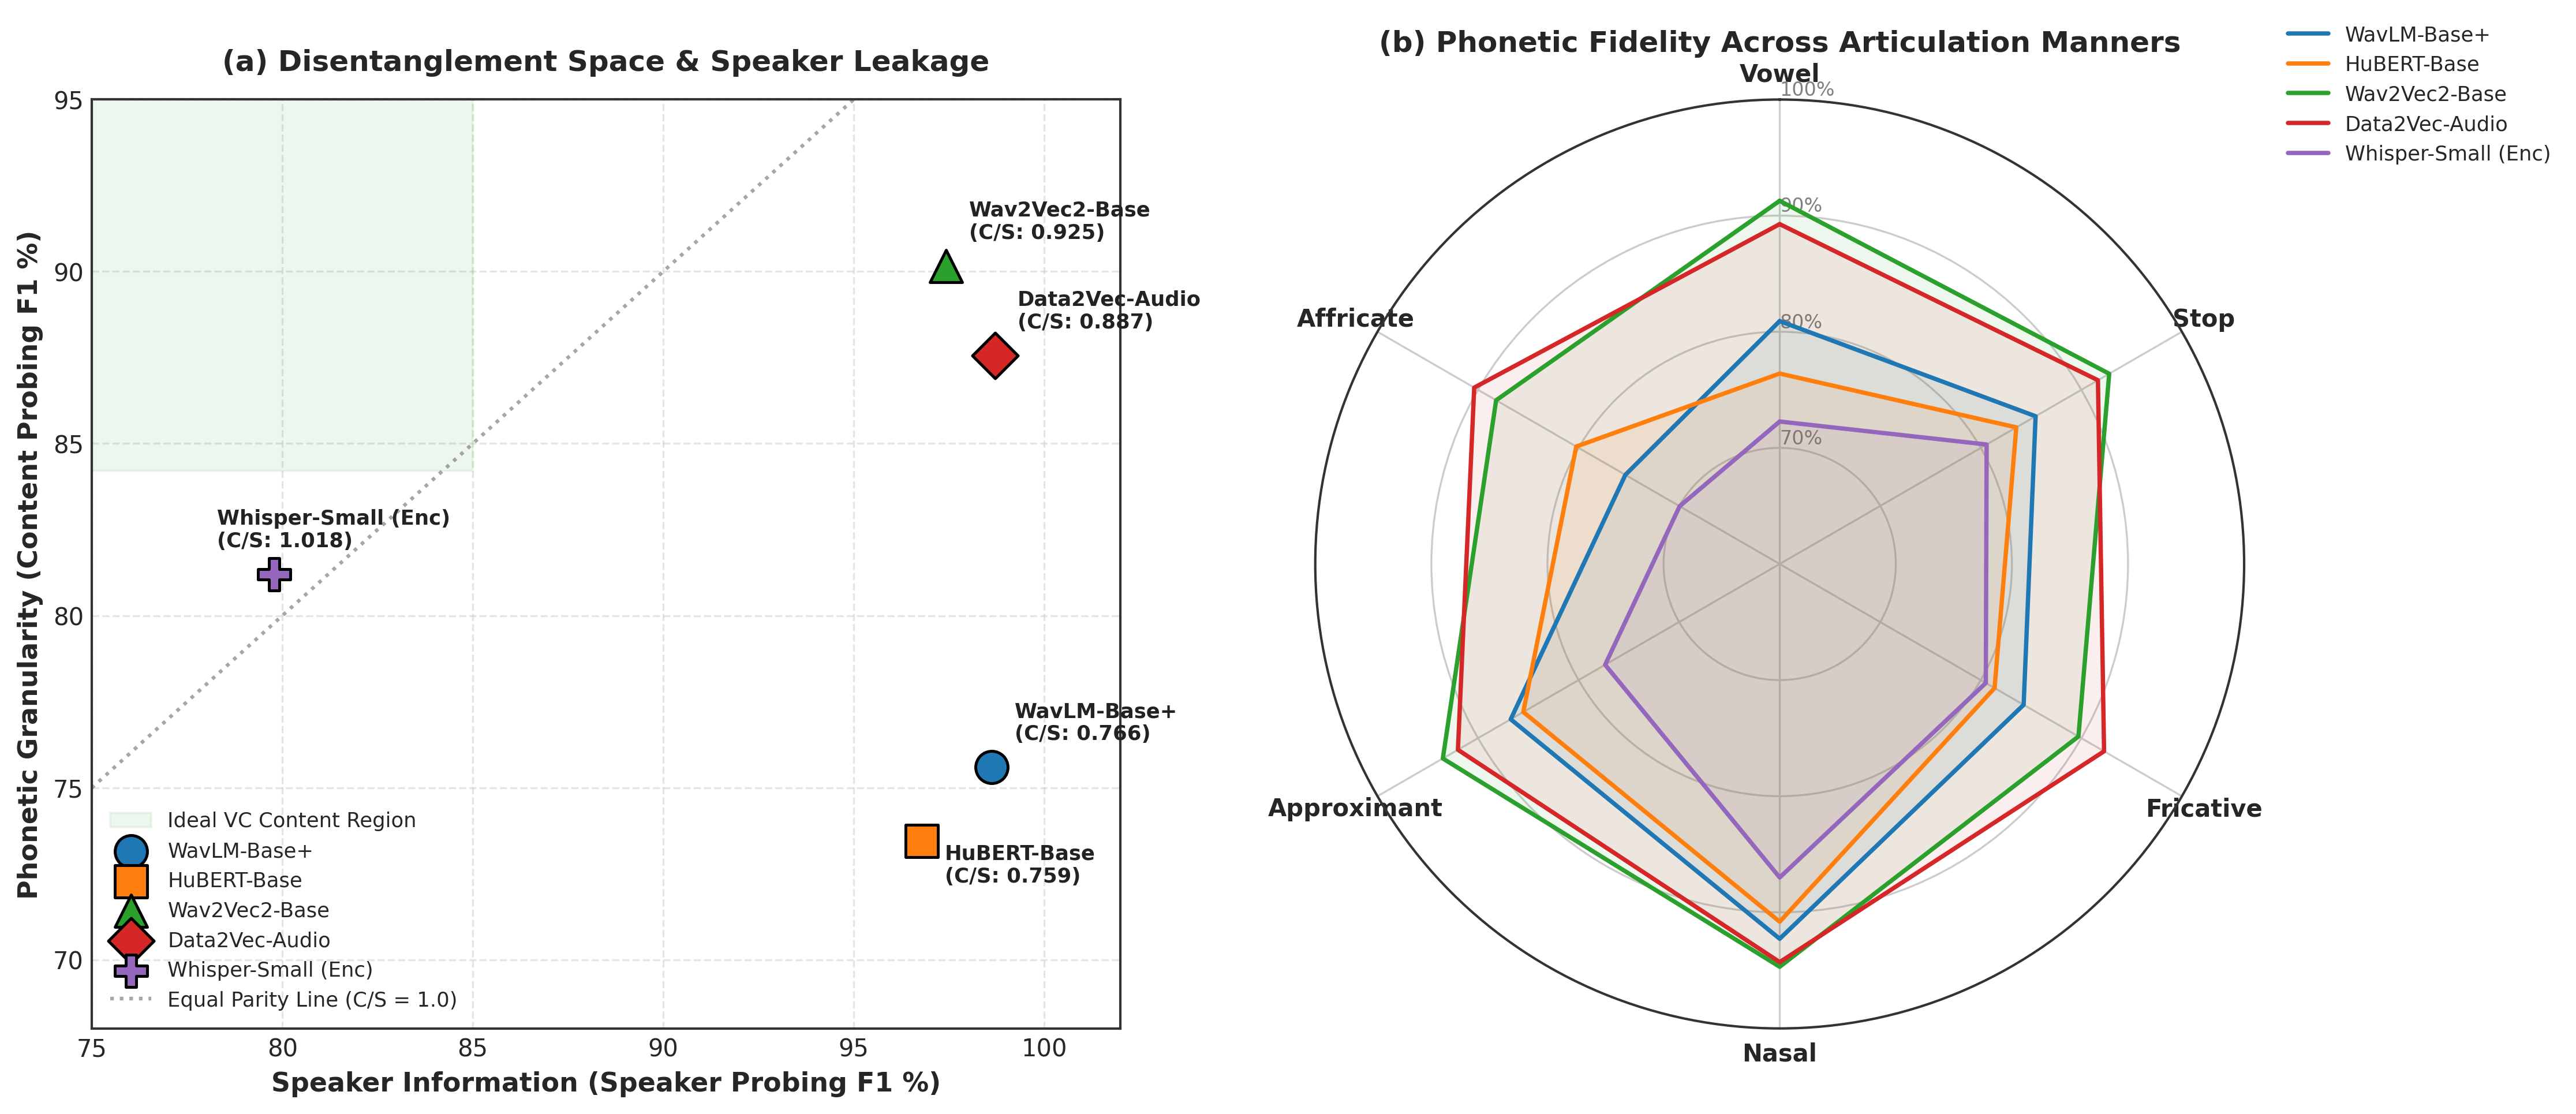

Figure 'disentanglement_composite_analysis.png' successfully generated!


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# تنظیمات استایل ژورنال
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.0

# ۱. داده‌های آزمایش‌ها
models = ['WavLM-Base+', 'HuBERT-Base', 'Wav2Vec2-Base', 'Data2Vec-Audio', 'Whisper-Small (Enc)']
speaker_f1 = [98.63, 96.79, 97.43, 98.71, 79.79]
content_f1 = [75.59, 73.45, 90.16, 87.56, 81.20]

manner_data = {
    'Categories': ['Vowel', 'Stop', 'Fricative', 'Nasal', 'Approximant', 'Affricate'],
    'WavLM-Base+': [80.92, 85.45, 84.26, 92.28, 86.75, 75.35],
    'HuBERT-Base': [76.40, 83.53, 81.37, 90.81, 85.50, 80.23],
    'Wav2Vec2-Base': [91.28, 92.77, 89.71, 94.69, 93.50, 88.20],
    'Data2Vec-Audio': [89.27, 91.65, 92.26, 94.29, 92.00, 90.38],
    'Whisper-Small (Enc)': [72.27, 80.58, 80.50, 87.00, 77.36, 69.95]
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
markers = ['o', 's', '^', 'D', 'P']

fig = plt.figure(figsize=(15, 6.5), dpi=300)

# ==============================================================================
# Panel A: Disentanglement Trade-off (Scatter & Frontier)
# ==============================================================================
ax1 = fig.add_subplot(1, 2, 1)

# ناحیه ایده‌آل Voice Conversion (محتوای بالا، نشت گوینده کم)
ax1.axvspan(70, 85, ymin=0.6, ymax=1.0, color='#2ca02c', alpha=0.08, label='Ideal VC Content Region')

for i, model in enumerate(models):
    ax1.scatter(speaker_f1[i], content_f1[i], color=colors[i], s=180, marker=markers[i],
                edgecolor='black', linewidth=1.2, zorder=5, label=model)
    
    # برچسب‌گذاری کنار نقاط
    offset_x = 0.6 if model != 'Whisper-Small (Enc)' else -1.5
    offset_y = -1.2 if 'HuBERT' in model else 0.8
    ax1.annotate(f"{model}\n(C/S: {content_f1[i]/speaker_f1[i]:.3f})", 
                 (speaker_f1[i] + offset_x, content_f1[i] + offset_y),
                 fontsize=8.5, fontweight='semibold', color='#222222')

# خط مرجع نسبت 1:1
ax1.plot([70, 100], [70, 100], linestyle=':', color='gray', alpha=0.7, label='Equal Parity Line (C/S = 1.0)')

ax1.set_xlabel('Speaker Information (Speaker Probing F1 %)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Phonetic Granularity (Content Probing F1 %)', fontsize=11, fontweight='bold')
ax1.set_title('(a) Disentanglement Space & Speaker Leakage', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlim(75, 102)
ax1.set_ylim(68, 95)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower left', fontsize=8.5, framealpha=0.9)

# ==============================================================================
# Panel B: Radar Chart for Manner of Articulation
# ==============================================================================
ax2 = fig.add_subplot(1, 2, 2, polar=True)

categories = manner_data['Categories']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # بستن حلقه

ax2.set_theta_offset(np.pi / 2)
ax2.set_theta_direction(-1)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=10, fontweight='bold')

# تنظیم دوایر شبکه
ax2.set_rlabel_position(0)
plt.yticks([70, 80, 90, 100], ["70%", "80%", "90%", "100%"], color="grey", size=8)
plt.ylim(60, 100)

for i, model in enumerate(models):
    values = manner_data[model]
    values += values[:1]
    ax2.plot(angles, values, linewidth=1.8, linestyle='solid', label=model, color=colors[i])
    ax2.fill(angles, values, color=colors[i], alpha=0.08)

ax2.set_title('(b) Phonetic Fidelity Across Articulation Manners', fontsize=12, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8.5, framealpha=0.95)

plt.tight_layout()
plt.savefig('disentanglement_composite_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 'disentanglement_composite_analysis.png' successfully generated!")


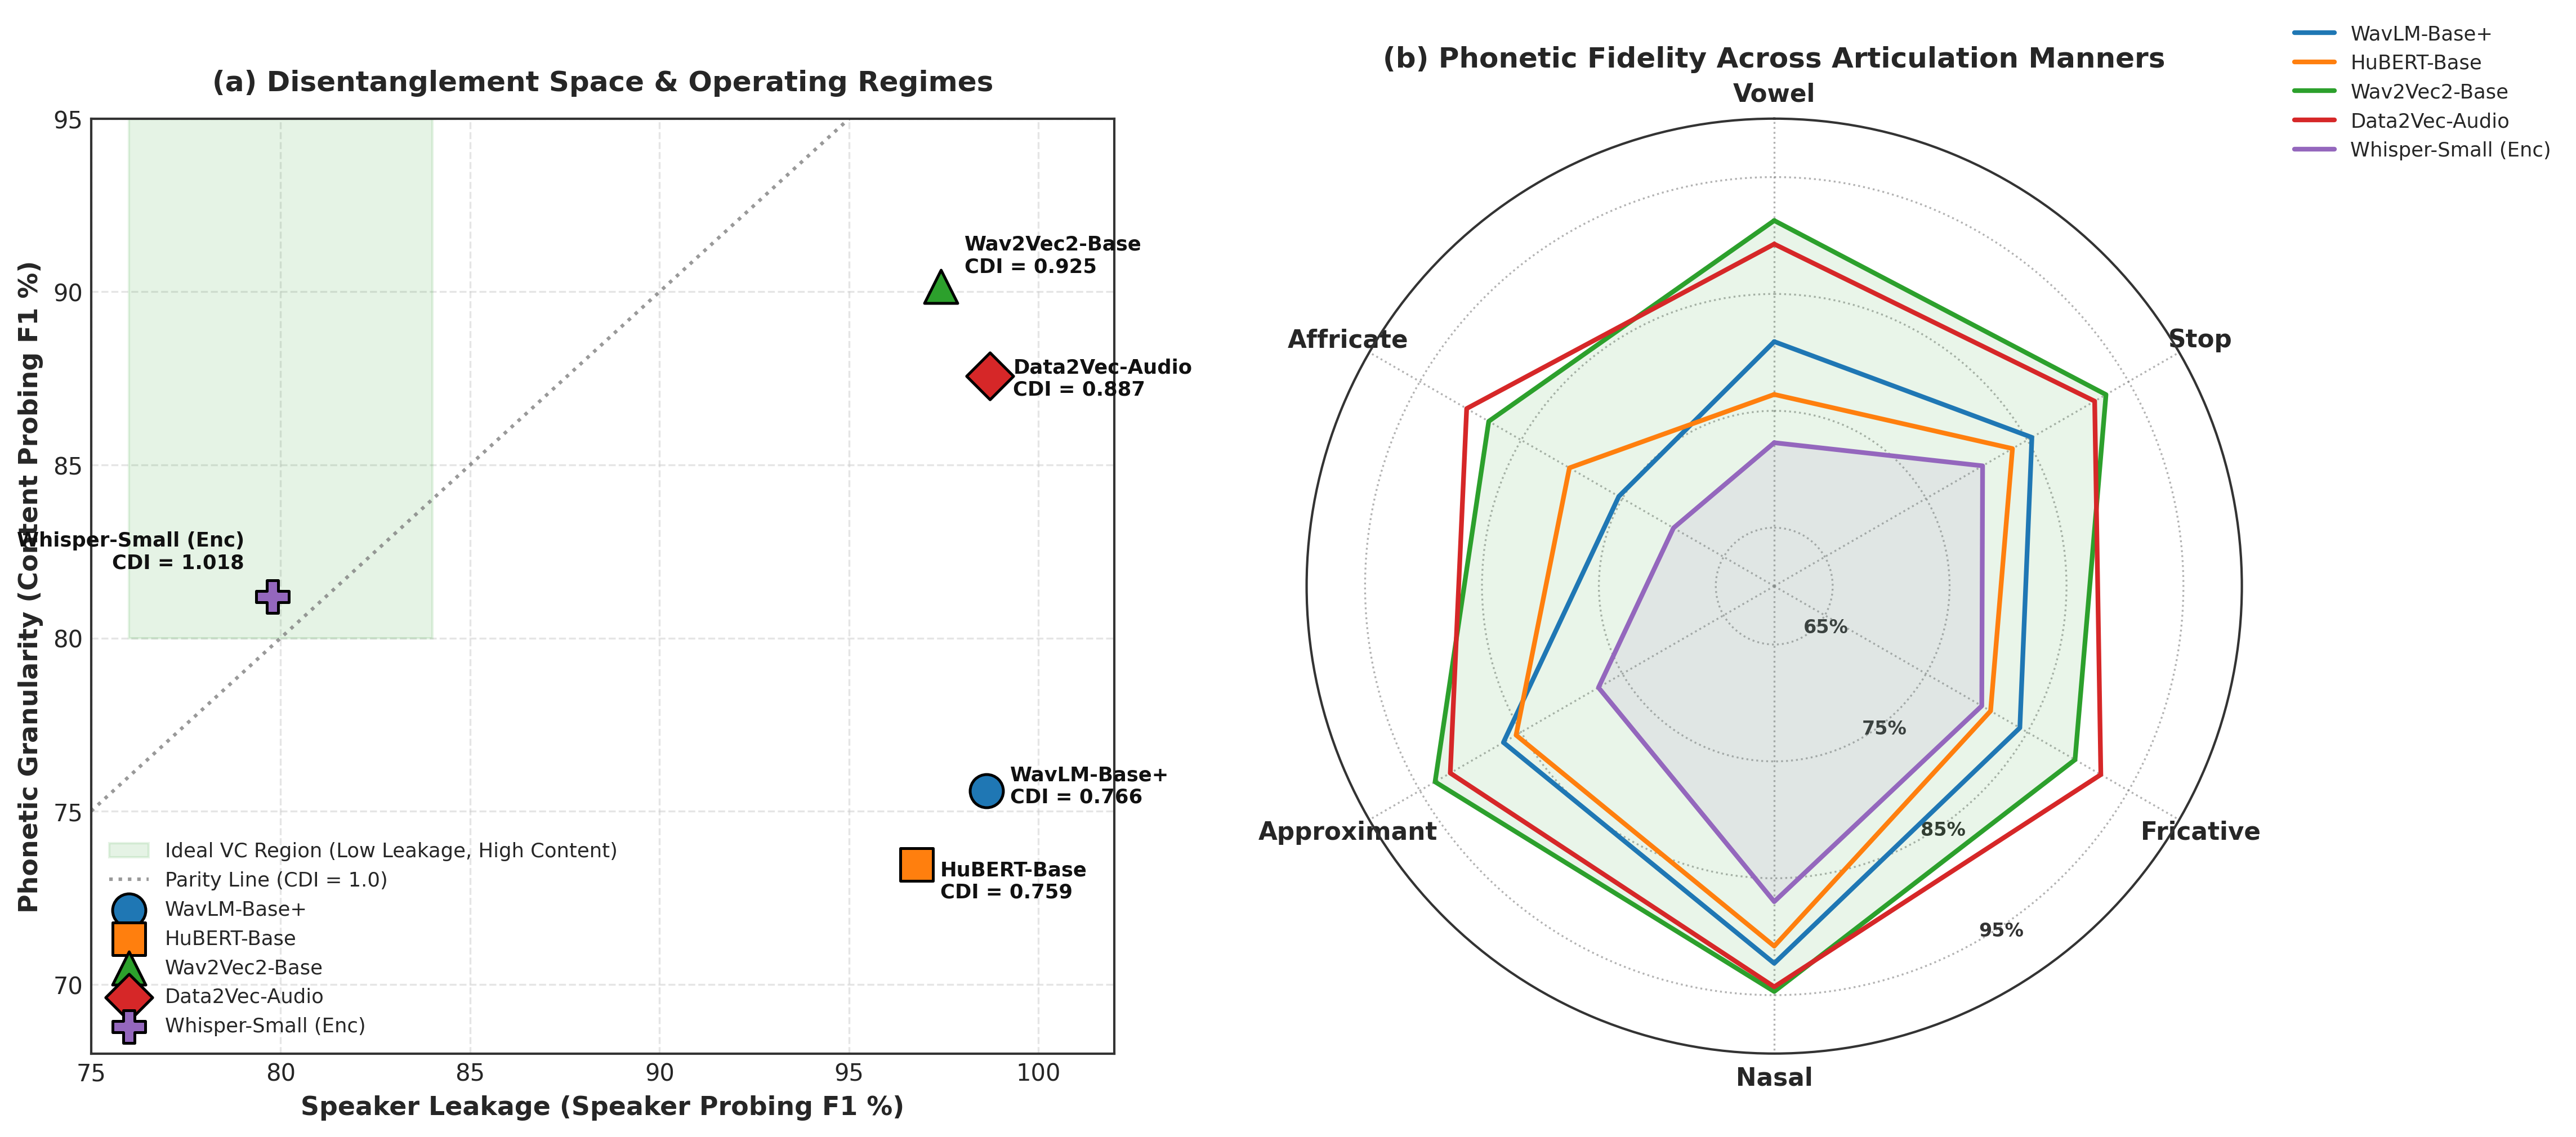

Figure 'disentanglement_composite_analysis_final.png' saved successfully!


In [43]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# ۱. داده‌های آزمایش‌ها
# ==============================================================================
models = ['WavLM-Base+', 'HuBERT-Base', 'Wav2Vec2-Base', 'Data2Vec-Audio', 'Whisper-Small (Enc)']
speaker_f1 = [98.63, 96.79, 97.43, 98.71, 79.79]
content_f1 = [75.59, 73.45, 90.16, 87.56, 81.20]

categories = ['Vowel', 'Stop', 'Fricative', 'Nasal', 'Approximant', 'Affricate']
manner_data = {
    'WavLM-Base+': [80.92, 85.45, 84.26, 92.28, 86.75, 75.35],
    'HuBERT-Base': [76.40, 83.53, 81.37, 90.81, 85.50, 80.23],
    'Wav2Vec2-Base': [91.28, 92.77, 89.71, 94.69, 93.50, 88.20],
    'Data2Vec-Audio': [89.27, 91.65, 92.26, 94.29, 92.00, 90.38],
    'Whisper-Small (Enc)': [72.27, 80.58, 80.50, 87.00, 77.36, 69.95]
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
markers = ['o', 's', '^', 'D', 'P']

# ==============================================================================
# ۲. ساخت شکل با کیفیت ژورنالی (300 DPI)
# ==============================================================================
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.0

fig = plt.figure(figsize=(15.5, 6.8), dpi=300)

# ------------------------------------------------------------------------------
# Panel A: Disentanglement Trade-off (Scatter Plot)
# ------------------------------------------------------------------------------
ax1 = fig.add_subplot(1, 2, 1)

# محدوده هدف تبدیل صدا (Ideal VC Region)
ax1.axvspan(76, 84, ymin=(80-68)/(95-68), ymax=1.0, 
            color='#2ca02c', alpha=0.12, label='Ideal VC Region (Low Leakage, High Content)')

# خط توازن Parity Line
ax1.plot([75, 102], [75, 102], linestyle=':', color='gray', alpha=0.8, label='Parity Line (CDI = 1.0)')

# رسم نقاط مدل‌ها
for i, model in enumerate(models):
    ax1.scatter(speaker_f1[i], content_f1[i], color=colors[i], s=200, marker=markers[i],
                edgecolor='black', linewidth=1.2, zorder=5, label=model)
    
    cdi_val = content_f1[i] / speaker_f1[i]
    # تنظیم هوشمند محل متن برای عدم هم‌پوشانی
    if 'Whisper' in model:
        xytext = (-12, 12)
        ha = 'right'
    elif 'HuBERT' in model:
        xytext = (10, -14)
        ha = 'left'
    elif 'WavLM' in model:
        xytext = (10, -5)
        ha = 'left'
    elif 'Data2Vec' in model:
        xytext = (10, -8)
        ha = 'left'
    else:  # Wav2Vec2
        xytext = (10, 6)
        ha = 'left'
        
    ax1.annotate(f"{model}\nCDI = {cdi_val:.3f}", 
                 (speaker_f1[i], content_f1[i]),
                 textcoords="offset points", xytext=xytext, ha=ha,
                 fontsize=8.5, fontweight='bold', color='#111111')

ax1.set_xlabel('Speaker Leakage (Speaker Probing F1 %)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Phonetic Granularity (Content Probing F1 %)', fontsize=11, fontweight='bold')
ax1.set_title('(a) Disentanglement Space & Operating Regimes', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlim(75, 102)
ax1.set_ylim(68, 95)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower left', fontsize=8.5, framealpha=0.95)

# ------------------------------------------------------------------------------
# Panel B: Manner of Articulation (Radar Chart)
# ------------------------------------------------------------------------------
ax2 = fig.add_subplot(1, 2, 2, polar=True)

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles_closed = angles + [angles[0]]  # حلقه بسته برای رسم

ax2.set_theta_offset(np.pi / 2)
ax2.set_theta_direction(-1)
ax2.set_xticks(angles)
ax2.set_xticklabels(categories, fontsize=10.5, fontweight='bold')

# تنظیم دقیق خطوط و مقادیر شعاعی
r_ticks = [65, 75, 85, 95]
ax2.set_yticks(r_ticks)
ax2.set_yticklabels([f"{t}%" for t in r_ticks], color="#333333", size=8, fontweight='bold')
ax2.set_ylim(60, 100)
ax2.set_rlabel_position(150)
ax2.grid(True, linestyle=':', color='gray', alpha=0.6)

# رسم خطوط مدل‌ها (فقط مدل‌های شاخص به صورت شفاف پر می‌شوند تا شکل شلوغ نشود)
for i, model in enumerate(models):
    vals = manner_data[model]
    vals_closed = vals + [vals[0]]
    
    ax2.plot(angles_closed, vals_closed, linewidth=2.0, linestyle='solid', label=model, color=colors[i])
    if model in ['Wav2Vec2-Base', 'Whisper-Small (Enc)']:
        ax2.fill(angles_closed, vals_closed, color=colors[i], alpha=0.10)

ax2.set_title('(b) Phonetic Fidelity Across Articulation Manners', fontsize=12, fontweight='bold', pad=22)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.12), fontsize=8.5, framealpha=0.95)

plt.tight_layout()
plt.savefig('disentanglement_composite_analysis_final.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 'disentanglement_composite_analysis_final.png' saved successfully!")
